# CLIMB — figure notebook

**Does unsupervised (MLM) pretraining on SMILES help a chemical language model, or can you skip it?**

Every figure in the paper is produced here, from the collected experiment data in `figure_data/`
(synced from `s3://climb-s3-bucket/experiments/`). §1 fixes fonts, colours and the save routine
once, so every panel is identically formatted; each figure is defined in exactly **one** cell and
exported to `figures_out/` as both PNG and PDF.

### Regime vocabulary (identical in every figure)
| term | meaning |
|---|---|
| **random** | chance model — 0.5 ROC-AUC / predict-the-mean RMSE. A reference *line*, never a bar. |
| **no_pretrain** | random-init ModernBERT, no pretraining, **frozen** features → head trained on the eval task. |
| **unsup_only** | MLM pretraining only, frozen features. |
| **sup_only** | random init → supervised fine-tune, no MLM (one arm per SFT recipe; on-disk dirs are still named `skip_*`). |
| **unsup→sup** | MLM, then supervised fine-tune — the realistic recipe. |

### The eight figures
| ID | Question it answers | Data |
|---|---|---|
| **A1** | Which model performs best across datasets? (tough held-out-scaffold split) | real |
| **A2** | How does pretraining scale in forward passes? | real (+ marked pending region) |
| **B1p1** | Does pretraining help small datasets more, and through which mechanism? | real |
| **E1** | With end-to-end deployment instead of a frozen probe, does pretraining pay off? | real |
| **B2** | If we pretrain on a *garbled* objective, do the benefits survive? | real once E13 lands, else marked placeholder |
| **C1J1** | Which SFT label type helps most, how much lift over `no_pretrain`, and does transfer track chemistry? | real |
| **I1** | Do corpus-similar or novel molecules benefit most from pretraining? | real |
| **H1** | Does SMILES enumeration beat canonical repetition? | real |

**Protocol matching.** Every panel compares arms evaluated the *same* way. A1/A2/B2/C1J1/H1 use the
single DeepChem scaffold hold-out; B1p1 uses the label-efficiency sweep; I1 needs per-molecule
predictions and so uses the 5-fold CV predictions for all of its arms. No panel mixes schemes.

## 1 · Global style — set once, applied to every figure

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from pathlib import Path

STYLE = dict(
    font_family="sans-serif", font_stack=["Arial","Helvetica","DejaVu Sans"],
    serif_stack=["Times New Roman","Nimbus Roman","DejaVu Serif"],
    fs_base=8, fs_axis_label=9, fs_title=9, fs_legend=7.5, fs_annot=7, fs_panel_tag=11,
    col1=3.50, col15=4.75, col2=7.20,
    lw=1.4, lw_thin=0.8, marker_size=5.0, cap_size=2.5, grid_alpha=0.30,
    dpi_screen=120, dpi_save=300, save_formats=("png","pdf"), outdir="figures_out",
)
def _install_rcparams(style=STYLE):
    fam=style["font_family"]; stack=style["font_stack"] if fam=="sans-serif" else style["serif_stack"]
    mpl.rcParams.update({
        "figure.dpi":style["dpi_screen"],"savefig.dpi":style["dpi_save"],
        "figure.facecolor":"white","savefig.facecolor":"white","savefig.bbox":"tight","savefig.pad_inches":0.03,
        "pdf.fonttype":42,"ps.fonttype":42,
        "font.family":fam,("font.sans-serif" if fam=="sans-serif" else "font.serif"):stack,
        "font.size":style["fs_base"],"axes.titlesize":style["fs_title"],"axes.labelsize":style["fs_axis_label"],
        "xtick.labelsize":style["fs_base"],"ytick.labelsize":style["fs_base"],"legend.fontsize":style["fs_legend"],
        "mathtext.default":"regular","axes.spines.top":False,"axes.spines.right":False,
        "axes.linewidth":0.8,"axes.edgecolor":"#333333","axes.labelcolor":"#111111",
        "axes.titlepad":4.0,"axes.titleweight":"bold",
        "xtick.direction":"out","ytick.direction":"out",
        "xtick.major.size":3.0,"ytick.major.size":3.0,"xtick.minor.size":1.6,"ytick.minor.size":1.6,
        "xtick.major.width":0.8,"ytick.major.width":0.8,"xtick.minor.width":0.6,"ytick.minor.width":0.6,
        "xtick.color":"#333333","ytick.color":"#333333","xtick.minor.visible":True,"ytick.minor.visible":True,
        "lines.linewidth":style["lw"],"lines.markersize":style["marker_size"],"lines.markeredgewidth":0.6,
        "axes.grid":True,"grid.color":"#B0B0B0","grid.linewidth":0.5,"grid.alpha":style["grid_alpha"],
        "axes.axisbelow":True,"legend.frameon":False,"legend.handlelength":1.4,
        "legend.columnspacing":1.0,"legend.labelspacing":0.35,
    })
_install_rcparams(); Path(STYLE["outdir"]).mkdir(exist_ok=True)
print("matplotlib",mpl.__version__,"| font ->",
      font_manager.FontProperties(family=mpl.rcParams["font.family"]).get_name(),
      "| out:",STYLE["outdir"])

matplotlib 3.9.4 | font -> Arial | out: figures_out


In [2]:
# ---- palette, regime registry, task registry: the single source of truth for colour + label ----
# Every figure reads colours from here, so a model has the same colour in A1, A2, B1p1 and B2 and
# the legend transfers between panels without the reader re-learning it.
PALETTE = dict(grey="#8A8A8A", grey2="#C4C4C4", black="#1A1A1A", blue="#4477AA", green="#228833",
               orange="#EE7733", red="#CC3311", teal="#009988", purple="#AA3377", cyan="#66CCEE",
               yellow="#CCBB44", sand="#DDCC77")

sup_recipes = ["dense","sparse_all","dense_plus_sparse","minimol_full","mixed"]
_recipe_pretty = {"dense":"dense (MTR)","sparse_all":"sparse_all","dense_plus_sparse":"dense+sparse",
                  "minimol_full":"minimol_full","mixed":"mixed"}
_recipe_color  = {"dense":PALETTE["orange"],"sparse_all":PALETTE["teal"],"dense_plus_sparse":PALETTE["red"],
                  "minimol_full":PALETTE["purple"],"mixed":PALETTE["cyan"]}
_recipe_marker = {"dense":"^","sparse_all":"v","dense_plus_sparse":"P","minimol_full":"X","mixed":"<"}

REGIME = {  # key : (colour, marker, linestyle, label)
    "random"      :(PALETTE["grey2"], None,(0,(1,1)),  "random (chance)"),
    "no_pretrain" :(PALETTE["grey"],  "o", (0,(3,2)),  "no_pretrain (frozen)"),
    "ecfp4"       :(PALETTE["black"], "D", (0,(4,1)),  "Morgan+XGBoost (ECFP4)"),
    "fp_desc"     :(PALETTE["sand"],  "s", (0,(4,1)),  "Morgan+desc+XGBoost"),
    "unsup_only"  :(PALETTE["blue"],  "o", "-",        "unsup_only (MLM)"),
    "unsup2sup"   :(PALETTE["green"], "s", "-",        "unsup→sup (MLM→SFT)"),
}
for r in sup_recipes:
    REGIME[f"sup_only:{r}"]=(_recipe_color[r],_recipe_marker[r],"-",f"sup_only: {_recipe_pretty[r]}")
# unsup->sup is reported PER SFT recipe (A1 splits it, so it is comparable with sup_only's five
# arms instead of averaging five different recipes into one bar). Green family = the regime, so
# the reader still sees "this is unsup->sup" at a glance; the shade tracks the recipe.
_u2s_color={"dense":"#228833","sparse_all":"#88CCAA","dense_plus_sparse":"#117744",
            "minimol_full":"#44BB99","mixed":"#7FB069"}
for r in sup_recipes:
    REGIME[f"unsup2sup:{r}"]=(_u2s_color[r],_recipe_marker[r],"-",f"unsup→sup: {_recipe_pretty[r]}")
# Random-init encoder FINE-TUNED end-to-end on the eval task (E1). Sits next to the frozen
# no_pretrain bar and answers a different question, so it gets its own grey, not a shared one.
REGIME["no_pretrain_e2e"]=("#555555","o",(0,(3,2)),"no_pretrain (end-to-end)")
rc_color=lambda k:REGIME[k][0]; rc_marker=lambda k:REGIME[k][1]
rc_ls   =lambda k:REGIME[k][2]; rc_label =lambda k:REGIME[k][3]

TASKS = {
    "ESOL"          :dict(metric="RMSE",   higher_better=False,pretty="ESOL", domain="solubility"),
    "BBBP"          :dict(metric="ROC-AUC",higher_better=True, pretty="BBBP", domain="ADMET"),
    "BACE"          :dict(metric="ROC-AUC",higher_better=True, pretty="BACE", domain="binding"),
    "Tox21"         :dict(metric="ROC-AUC",higher_better=True, pretty="Tox21",domain="toxicity"),
    "QM7"           :dict(metric="RMSE",   higher_better=False,pretty="QM7",  domain="quantum"),
    # HIV is scored by NEF1% (top-1% early enrichment) -- the virtual-screening readout. Chance is
    # the active fraction (1443/41120), not 0.5.
    "HIV"           :dict(metric="NEF1%",  higher_better=True, pretty="HIV",  domain="virtual screening",
                          suite_key="HIV_nef1", chance=0.0351),
    "Lipophilicity" :dict(metric="RMSE",   higher_better=False,pretty="Lipo.",domain="ADMET"),
}
CORE_TASKS=["ESOL","BBBP","BACE","Tox21","QM7","HIV"]
BUDGET_FP={"2M":2e6,"8M":8e6,"24M":24e6,"48M":48e6,"96M":96e6}
MATCHED_BUDGET="8M"          # largest budget where every arm ran to completion
U2S_SFT_FP=2e6               # unsup->sup spends its MLM base PLUS a 2M-FP SFT stage

def chance_value(task):
    return TASKS[task].get("chance", 0.5 if TASKS[task]["higher_better"] else 1.0)
def mlabel(task):
    m=TASKS[task]; return f'{m["metric"]} {"↑" if m["higher_better"] else "↓"}'
def ttitle(task,oneline=False):
    sep=" " if oneline else "\n"; return f'{TASKS[task]["pretty"]}{sep}({mlabel(task)})'
def lift(value,task,floor):
    """Improvement over the no_pretrain floor; positive = better for BOTH metric directions."""
    if not np.isfinite(floor) or floor==0 or not np.isfinite(value): return np.nan
    return (value-floor)/floor if TASKS[task]["higher_better"] else (floor-value)/floor

# ---- shared drawing helpers ----
def set_fp_axis(ax,budgets):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator(list(budgets)))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([f"{int(b/1e6)}M" for b in budgets]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
def label_all_yticks(ax,n=5):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n)); ax.yaxis.set_minor_locator(ticker.NullLocator())
def panel_tag(ax,tag,dx=-0.12,dy=1.02):
    ax.text(dx,dy,tag,transform=ax.transAxes,fontsize=STYLE["fs_panel_tag"],fontweight="bold",va="bottom",ha="right")
def add_chance_line(ax,task):
    ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)
def no_data_watermark(ax,need):
    ax.text(0.5,0.5,f"NO DATA\n{need}",transform=ax.transAxes,ha="center",va="center",
            fontsize=STYLE["fs_annot"]+1,color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4",fc="#FCE8E8",ec="#B00020",lw=0.8),zorder=5)
    for s in ax.spines.values(): s.set_linestyle((0,(3,3)))
def save_fig(fig,name):
    for ext in STYLE["save_formats"]: fig.savefig(f'{STYLE["outdir"]}/{name}.{ext}')
    print("saved",name)

import numpy as np
print("registry ready:",len(REGIME),"regimes,",len(TASKS),"tasks")

registry ready: 17 regimes, 7 tasks


## 2 · Load the experiment data

One tidy table per evaluation scheme. **Completion is derived**, never assumed: a run enters the
figures only if `verified.json` exists or its achieved forward passes reach ≥98 % of budget.
Missing evidence is reported as `unknown` and printed loudly rather than treated as fine — a
hand-maintained blocklist cannot catch a *newly* truncated run, which is exactly how half-trained
models reached plots before.

In [3]:
import json, re, glob, os
import numpy as np, pandas as pd
DATA_ROOT=Path("figure_data")

def _achieved_fp(run_dir):
    """Last forward_passes_seen in metrics.jsonl; None if unavailable."""
    m=run_dir/"metrics.jsonl"
    if not m.exists(): return None
    last=""
    try:
        with m.open() as fh:
            for line in fh:
                if line.strip(): last=line
    except OSError: return None
    try: return float(json.loads(last).get("forward_passes_seen",0) or 0)
    except Exception: return None

def run_completion(run_dir,budget_fp,tol=0.98):
    """-> (status, achieved_fp); status in {complete, truncated, unknown, n/a}."""
    if (run_dir/"verified.json").exists(): return "complete",budget_fp
    # Anchors and random baselines have no forward-pass budget, so nothing could be truncated.
    # Flagging them would train the reader to ignore the warning, defeating its purpose.
    if not np.isfinite(budget_fp) or not budget_fp: return "n/a",np.nan
    fp=_achieved_fp(run_dir)
    if fp is None: return "unknown",np.nan
    return ("complete" if fp>=tol*budget_fp else "truncated"),fp

_UNKNOWN_RUNS=set()

def load_suite(run_dir,sub="moleculenet"):
    p=run_dir/sub/"suite_summary.json"
    if not p.exists(): return None
    d=json.loads(p.read_text()); out={}
    for k,v in d.items():
        if k.endswith("_MEAN"): out[(k[:-5],"mean")]=v
        elif k.endswith("_STD"): out[(k[:-4],"std")]=v
    return out

def _eval_mtime(run_dir,sub):
    """When this run's summary was written. Re-scoring the SAME encoder with the current eval_v2
    moves metrics by up to ~0.03 (head-seed noise plus code drift), so a panel that mixes an old
    summary with a fresh one is comparing two protocols. Carrying the timestamp makes that
    detectable instead of invisible."""
    p=run_dir/sub/"suite_summary.json"
    return pd.Timestamp(p.stat().st_mtime,unit="s") if p.exists() else pd.NaT

def parse_run(name):
    """Directory name -> regime/recipe/budget/seed, or None if it is not a plottable run."""
    # Pretraining-seed replicates are "<base>_s1"/"_s2". Parse the base and carry the seed, so
    # replicates aggregate instead of being silently dropped.
    m=re.match(r"(.+)_s(\d+)$",name)
    if m:
        base=parse_run(m.group(1))
        return {**base,"seed":int(m.group(2))} if base else None
    if name=="ecfp4_anchor":   return dict(seed=0,regime="ecfp4",  recipe=None,budget_label=None,budget_fp=np.nan)
    if name=="fp_desc_anchor": return dict(seed=0,regime="fp_desc",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("random_baseline"):
        return dict(seed=0,regime="no_pretrain",recipe=None,budget_label=None,budget_fp=np.nan)
    # Random-init encoder fine-tuned END-TO-END on the eval task (E1), scored by the A1 protocol.
    # No pretraining budget, so nothing here can be truncated.
    if name.startswith("e2e_random"):
        return dict(seed=0,regime="no_pretrain_e2e",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("corrupt_"):
        m=re.match(r"corrupt_(mlm|mtr)_(\d+M)$",name)
        if m: return dict(seed=0,regime=f"corrupt_{m[1]}",recipe=None,budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
        return None
    m=re.match(r"unsup_(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup_only",recipe=None,budget_label=m[1],budget_fp=BUDGET_FP[m[1]])
    m=re.match(r"skip_(.+)_(\d+M)$",name)      # dir names still 'skip_*'; the regime is sup_only
    if m: return dict(seed=0,regime="sup_only",recipe=m[1],budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
    # unsup->sup: MLM base of <budget> FP, then a 2M-FP SFT stage. budget_label keys off the BASE
    # so it lines up with the same-budget arms; budget_fp is the TRUE total, so the compute axis
    # in A2 is not flattering to this arm.
    m=re.match(r"u2s_(.+)_from(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup2sup",recipe=m[1],budget_label=m[2],
                      budget_fp=BUDGET_FP[m[2]]+U2S_SFT_FP)
    return None

def build_table(sub):
    rows=[]
    for wave in ["climb_v2_phase2","climb_v2_headline"]:
        for rd in sorted((DATA_ROOT/wave).glob("*/")):
            meta=parse_run(rd.name)
            if meta is None: continue
            suite=load_suite(rd,sub=sub)
            if not suite: continue
            st,fp=run_completion(rd,meta["budget_fp"])
            if st=="unknown": _UNKNOWN_RUNS.add(rd.name)
            for task in TASKS:
                sk=TASKS[task].get("suite_key",task)
                if (sk,"mean") in suite:
                    rows.append(dict(wave=wave,run=rd.name,task=task,value=suite[(sk,"mean")],
                                     std=suite.get((sk,"std"),np.nan),truncated=(st=="truncated"),
                                     evaluated_at=_eval_mtime(rd,sub),
                                     achieved_fp=(fp if np.isfinite(fp) else meta["budget_fp"]),**meta))
    return pd.DataFrame(rows)

# DEFAULT for every bar/ladder figure: the single DeepChem scaffold hold-out. It puts the RAREST
# scaffolds in test and therefore actually discriminates; the balanced 5-fold CV saturates (a
# random encoder reaches 0.937 on BBBP vs ~0.70 published) and compresses regime gaps 2-3x.
DF    = build_table("moleculenet")
DF_CV = build_table("moleculenet_cv")     # used only where per-fold predictions are needed (I1)

print(f"single-split: {len(DF):5d} rows / {DF.run.nunique()} runs")
print(f"5-fold CV   : {len(DF_CV):5d} rows / {DF_CV.run.nunique()} runs")
trunc=sorted(DF[DF.truncated].run.unique())
if trunc:
    print(f"\nTRUNCATED, excluded from every figure ({len(trunc)}) - derived from achieved FP:")
    for r in trunc:
        row=DF[DF.run==r].iloc[0]
        print(f"   {r:32s} {row.achieved_fp/1e6:5.1f}M / {row.budget_fp/1e6:.0f}M "
              f"({100*row.achieved_fp/row.budget_fp:.0f}%)")
if _UNKNOWN_RUNS:
    print(f"\n⚠ UNKNOWN COMPLETENESS ({len(_UNKNOWN_RUNS)} runs): no verified.json and no metrics.jsonl.")
    print("  Plotted on trust. 'No evidence' is not 'fine'. Sync evidence with:")
    print("    aws s3 sync s3://climb-s3-bucket/experiments/<wave> figure_data/<wave> \\")
    print("      --exclude '*' --include '*/verified.json' --include '*/metrics.jsonl'")
    for r in sorted(_UNKNOWN_RUNS)[:10]: print(f"    - {r}")

# ---- evaluation-protocol audit ------------------------------------------------------------
# Every arm inside one panel must have been scored by the same eval code. Runs scored more than a
# few days apart may not have been.
for _name,_d in (("single-split",DF),("5-fold CV",DF_CV)):
    _t=_d.dropna(subset=["evaluated_at"]).evaluated_at
    if len(_t):
        _span=(_t.max()-_t.min()).days
        _flag="  <-- MIXED: re-scoring in progress, figures are PROVISIONAL" if _span>2 else ""
        print(f"{_name:<12} evaluated {_t.min():%Y-%m-%d} .. {_t.max():%Y-%m-%d} "
              f"(span {_span}d){_flag}")

# ---- HIV coverage audit -------------------------------------------------------------------
# HIV was added to the eval suite after most runs were scored, so it is the one task that can be
# missing for an arm that is otherwise complete. Print it rather than letting bars quietly vanish.
_hiv=set(DF[DF.task=="HIV"].run); _all=set(DF.run)
if _all-_hiv:
    print(f"\nHIV (NEF1%) not yet scored for {len(_all-_hiv)}/{len(_all)} single-split runs; their HIV "
          f"bars are drawn as 'pending', never as zero:")
    print("   "+", ".join(sorted(_all-_hiv)[:12])+(" ..." if len(_all-_hiv)>12 else ""))

single-split:   538 rows / 74 runs
5-fold CV   :   310 rows / 48 runs
single-split evaluated 2026-07-15 .. 2026-07-22 (span 7d)  <-- MIXED: re-scoring in progress, figures are PROVISIONAL
5-fold CV    evaluated 2026-07-21 .. 2026-07-22 (span 1d)


In [4]:
# ---- helpers every figure shares: the no_pretrain floor and arm selection -------------------
def npt_floor(df,task,wave="climb_v2_phase2"):
    """Mean of the three random-init encoders — the 'neither pretraining nor labels' reference."""
    s=df[(df.wave==wave)&(df.regime=="no_pretrain")&(df.task==task)]
    return s.value.mean() if len(s) else np.nan

def arm_rows(df,task,key,budget=None,wave="climb_v2_phase2"):
    """All rows (across pretraining seeds) for one arm at one budget. Truncated runs excluded."""
    budget=budget or MATCHED_BUDGET
    b=(df.wave==wave)&(df.task==task)
    if key=="no_pretrain":        return df[b&(df.regime=="no_pretrain")]
    if key in ("ecfp4","fp_desc"):return df[b&(df.regime==key)]
    if key=="unsup_only":         return df[b&(df.regime=="unsup_only")&(df.budget_label==budget)&(~df.truncated)]
    if key=="no_pretrain_e2e":    return df[b&(df.regime=="no_pretrain_e2e")]
    if key=="unsup2sup":          return df[b&(df.regime=="unsup2sup")&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("unsup2sup:"):   # one recipe, not the mean of all five
        return df[b&(df.regime=="unsup2sup")&(df.recipe==key.split(":")[1])&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("sup_only:"):
        return df[b&(df.regime=="sup_only")&(df.recipe==key.split(":")[1])&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("corrupt_"):return df[b&(df.regime==key)&(df.budget_label==budget)&(~df.truncated)]
    return df.iloc[0:0]

def arm_value(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return s.value.mean() if len(s) else np.nan

def arm_err(df,task,key,budget=None):
    """Prefer PRETRAINING-SEED spread where replicates exist: it is the dominant noise source and
    what a reader assumes an error bar means. Head-seed std alone understates it. Arms with one
    pretraining seed fall back to head-seed std -- so the bars are NOT the same quantity across
    arms, which the caption states rather than hides."""
    s=arm_rows(df,task,key,budget)
    if not len(s): return np.nan
    if s.seed.nunique()>1:
        return float(np.nanstd(s.groupby("seed").value.mean().values,ddof=1))
    return float(np.nanmean(s["std"].values))

def n_seeds(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return int(s.seed.nunique()) if len(s) else 0

# ---- how many UNIQUE molecules an arm actually sees -------------------------------------------
# Forward passes are not molecules. Within one epoch they coincide; past it the stream repeats.
# The unsupervised corpus is ~12M (README 6.1) and each SFT recipe is capped per family
# (config_v2.SUPERVISED_FAMILY_CAPS x README 6.3 sizes), so the sparse recipes exhaust their pool
# after ~0.5M molecules and every further forward pass is pure repetition. A2.b makes that visible;
# Table A1 quotes the same numbers, from here, so the two can never disagree.
UNSUP_CORPUS=12_000_000
_FAM_AVAIL=dict(PCBA=1_517_000,L1000_MCF7=11_718,L1000_VCAP=7_800,PCQM=3_810_323,WONG=34_652)
_FAM_CAP  =dict(PCBA=500_000,L1000_MCF7=100_000,L1000_VCAP=100_000,PCQM=200_000,WONG=100_000)
_GROUP    =dict(sparse_all=["PCBA","L1000_MCF7","L1000_VCAP"],
                minimol_full=["PCBA","L1000_MCF7","L1000_VCAP","PCQM","WONG"])
ASSAY_POOL={g:sum(min(_FAM_AVAIL[f],_FAM_CAP[f]) for f in fams) for g,fams in _GROUP.items()}
# recipe -> (mtr weight, supervised weight, assay group). `dense` is MTR on the PubChem corpus with
# COMPUTED descriptor labels, so its labelled molecules come from the unsupervised corpus.
SFT_STREAMS={"dense":(1.0,0.0,None),"sparse_all":(0.0,1.0,"sparse_all"),
             "dense_plus_sparse":(0.5,0.5,"sparse_all"),"minimol_full":(0.0,1.0,"minimol_full"),
             "mixed":(0.5,0.5,"minimol_full")}

def sft_molecules(recipe,sft_fp):
    """(descriptor-labelled, assay-labelled) unique molecules an SFT stage of `sft_fp` FP touches."""
    w_mtr,w_sup,group=SFT_STREAMS[recipe]
    return (min(w_mtr*sft_fp,UNSUP_CORPUS) if w_mtr else 0,
            min(w_sup*sft_fp,ASSAY_POOL[group]) if w_sup else 0)

def unique_molecules(key,budget_fp):
    """Total unique molecules behind an arm at one budget. `budget_fp` is the DF value, i.e. for
    unsup->sup it already includes the 2M-FP SFT stage."""
    if not np.isfinite(budget_fp): return np.nan
    if key=="unsup_only":        return min(budget_fp,UNSUP_CORPUS)
    if key.startswith("sup_only:"):
        return sum(sft_molecules(key.split(":")[1],budget_fp))
    if key.startswith("unsup2sup:"):
        base=budget_fp-U2S_SFT_FP
        return min(base,UNSUP_CORPUS)+sum(sft_molecules(key.split(":")[1],U2S_SFT_FP))
    return np.nan

_MOLCOUNT={}
def n_molecules(task,sub="moleculenet_cv",wave="climb_v2_phase2"):
    """How many molecules this task actually scores under one evaluation scheme.

    Derived from the per-molecule prediction dumps, never hard-coded: the suite has gained tasks
    (Lipophilicity, HIV) and been re-split during the project, and a stale constant in a panel
    title is a claim the reader cannot check. `moleculenet_cv` predicts EVERY molecule
    out-of-fold, so its count is the dataset size; `moleculenet` counts the single hold-out's
    test split only. Returns NaN if no run has scored the task yet."""
    key=(task,sub,wave)
    if key not in _MOLCOUNT:
        n=np.nan
        for rd in sorted((DATA_ROOT/wave).glob("*/")):
            p=rd/sub/"test_predictions.csv"
            if not p.exists(): continue
            d=pd.read_csv(p,usecols=["dataset","mol_index"])
            d=d[d.dataset==task]
            if len(d): n=int(d.mol_index.nunique()); break
        _MOLCOUNT[key]=n
    return _MOLCOUNT[key]

def best_sup_recipe(df,budget=None,tasks=None):
    """The sup_only recipe with the highest MEAN lift over no_pretrain. Resolved from the data so
    it cannot go stale as runs land."""
    tasks=tasks or CORE_TASKS; best,best_v=None,-np.inf
    for r in sup_recipes:
        vals=[lift(arm_value(df,t,f"sup_only:{r}",budget),t,npt_floor(df,t)) for t in tasks]
        vals=[v for v in vals if np.isfinite(v)]
        if vals and np.mean(vals)>best_v: best,best_v=r,float(np.mean(vals))
    return best or "dense", best_v

BEST_SUP,_bv = best_sup_recipe(DF)
print(f"best sup_only recipe at {MATCHED_BUDGET} = {BEST_SUP!r} (mean lift {100*_bv:+.1f}% over no_pretrain)")
print("PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:"+BEST_SUP+", unsup→sup")

best sup_only recipe at 8M = 'dense' (mean lift +12.4% over no_pretrain)
PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:dense, unsup→sup


## A1 · Which model performs best across datasets?

Bars = one model per arm at a compute-matched **8 M forward-pass** budget. The same arms, order and
colours are drawn twice, on the two evaluation schemes, because they resolve the question very
differently:

- **A1.a — single DeepChem scaffold hold-out** (rarest scaffolds in test). This is the tough,
  realistic split, but its test set is only **113 / 152 / 204 molecules** on ESOL / BACE / BBBP, so
  it has almost no power to separate arms (see Table A1.a: most tasks end in a 6–13-way tie).
- **A1.b — pooled 5-fold scaffold cross-validation.** Every molecule is predicted out-of-fold, which
  is 10–35× the test molecules and is the protocol README §8.1 already names as the test of record.
  This is the panel the paper's claims should rest on.

The dotted line is chance. `no_pretrain` is a real ~41 M-parameter random-init encoder with a trained
head, so it sits well above chance — the question is whether any pretraining recipe beats **it**, not
whether it beats chance. `no_pretrain (end-to-end)` is the same random-init encoder *fine-tuned* on
the downstream task, i.e. the from-scratch baseline a practitioner would actually try first.

The bars show three SFT recipes (`dense`, `sparse_all`, `dense+sparse`) for each of `sup_only` and
`unsup→sup`; `minimol_full` and `mixed` are omitted from the plot for legibility and reported in
Table A1 instead. Error bars: ±1 sd over **pretraining seeds** where replicates exist, else over head
seeds (A1.a) or folds (A1.b). The two are different quantities; the caption says which arms have which.

saved figA1a_best_model_headline_holdout


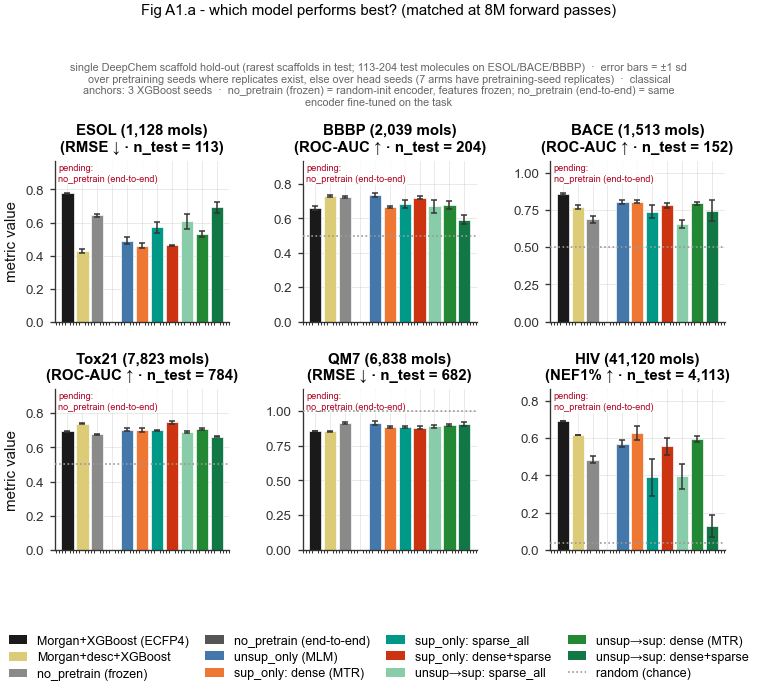


A1.a mean lift over no_pretrain at 8M (tasks scored / 6):
   Morgan+XGBoost (ECFP4)           +7.8%   (n=6)
   Morgan+desc+XGBoost             +15.1%   (n=6)
   no_pretrain (frozen)             +0.0%   (n=6)
   unsup_only (MLM)                +10.7%   (n=6)
   sup_only: dense (MTR)           +12.4%   (n=6)
   sup_only: sparse_all             +0.0%   (n=6)
   sup_only: dense+sparse          +11.8%   (n=6)
   unsup→sup: sparse_all            -3.3%   (n=6)
   unsup→sup: dense (MTR)           +9.3%   (n=6)
   unsup→sup: dense+sparse         -15.3%   (n=6)


saved figA1b_best_model_headline_cv


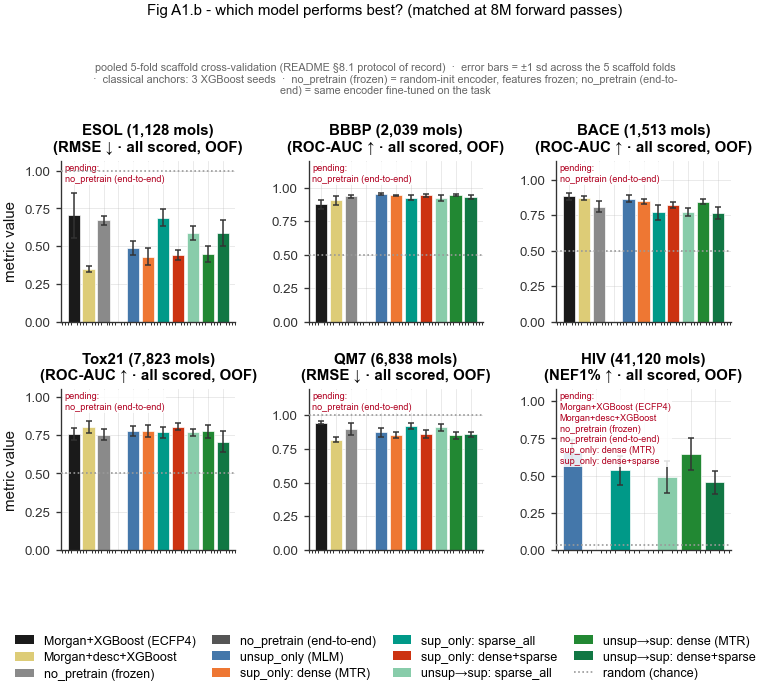


A1.b mean lift over no_pretrain at 8M (tasks scored / 6):
   Morgan+XGBoost (ECFP4)           -1.5%   (n=5)
   Morgan+desc+XGBoost             +13.5%   (n=5)
   no_pretrain (frozen)             +0.0%   (n=5)
   unsup_only (MLM)                 +8.4%   (n=5)
   sup_only: dense (MTR)            +9.9%   (n=5)
   sup_only: sparse_all             -1.8%   (n=5)
   sup_only: dense+sparse           +9.4%   (n=5)
   unsup→sup: sparse_all            +1.4%   (n=5)
   unsup→sup: dense (MTR)           +9.3%   (n=5)
   unsup→sup: dense+sparse          +0.9%   (n=5)


In [5]:
# ---------- A1 · headline bars at the matched budget, drawn on BOTH evaluation schemes ----------
# A1.a = single DeepChem scaffold hold-out (rarest scaffolds in test, 113-204 molecules on the
#        small tasks). A1.b = pooled 5-fold scaffold CV (README §8.1's protocol of record;
#        10-35x the test molecules, so it is the one that can actually separate arms).
# Same arms, same order, same colours in both panels so they are read side by side.
import textwrap as _tw          # module scope: later figures (E1) reuse this alias
A1_ORDER = ["ecfp4", "fp_desc", "no_pretrain", "no_pretrain_e2e", "unsup_only",
            "sup_only:dense", "sup_only:sparse_all", "sup_only:dense_plus_sparse",
            "unsup2sup:sparse_all", "unsup2sup:dense", "unsup2sup:dense_plus_sparse"]
# `minimol_full` and `mixed` are deliberately absent from the BARS (11 is already crowded); both
# recipes are still reported for both regimes in Table A1 below, which covers all five.

def a1_title(task, sub):
    """`ESOL (1,128 mols)` over `(RMSE ↓ · n_test = 113)` -- the second number is the whole point
    of splitting A1 into a/b, so it belongs in the panel, not only in the caption."""
    tot, n = n_molecules(task, "moleculenet_cv"), n_molecules(task, sub)
    head = f'{TASKS[task]["pretty"]} ({tot:,} mols)' if np.isfinite(tot) else TASKS[task]["pretty"]
    if not np.isfinite(n):        tail = mlabel(task)
    elif n == tot:                tail = f'{mlabel(task)} · all scored, OOF'   # CV: no held-out remainder
    else:                         tail = f'{mlabel(task)} · n_test = {n:,}'
    return f"{head}\n({tail})"

def draw_A1(df, sub, tag, scheme_note, err_note, fname):
    ncol = 3; nrow = int(np.ceil(len(CORE_TASKS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(STYLE["col2"], 2.35 * nrow)); axes = axes.ravel()
    for ax, task in zip(axes, CORE_TASKS):
        vals = [arm_value(df, task, k) for k in A1_ORDER]
        errs = [arm_err(df, task, k)   for k in A1_ORDER]
        x = np.arange(len(A1_ORDER))
        for xi, k, v, e in zip(x, A1_ORDER, vals, errs):
            if not np.isfinite(v): continue
            ax.bar(xi, v, color=rc_color(k), edgecolor="white", lw=0.4, width=0.82,
                   yerr=(e if np.isfinite(e) else None),
                   error_kw=dict(ecolor="#333333", elinewidth=0.9, capsize=2, capthick=0.9))
        # A missing bar simply vanishes, which a reader cannot tell from a zero-height bar. Name them.
        pending = [rc_label(k) for k, v in zip(A1_ORDER, vals) if not np.isfinite(v)]
        if pending:
            ax.set_ylim(top=ax.get_ylim()[1] * (1.10 + 0.09 * int(np.ceil(len(pending) / 2))))
            ax.text(0.02, 0.985, "pending:\n" + "\n".join(pending), transform=ax.transAxes,
                    ha="left", va="top", fontsize=STYLE["fs_annot"] - 1.5, color="#B00020",
                    linespacing=1.25, bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.0))
        add_chance_line(ax, task)
        ax.set_title(a1_title(task, sub), pad=6); ax.set_xticks(x); ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0); ax.margins(x=0.04); label_all_yticks(ax)
    for ax in axes[len(CORE_TASKS):]: ax.axis("off")
    for i in range(0, len(CORE_TASKS), ncol): axes[i].set_ylabel("metric value")

    handles = [mpl.patches.Patch(facecolor=rc_color(k), label=rc_label(k)) for k in A1_ORDER]
    handles += [plt.Line2D([], [], color="#999999", ls=(0, (1, 1.5)), lw=1.0, label="random (chance)")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=STYLE["fs_legend"], handlelength=1.5, columnspacing=1.3)

    # replication note; the count of replicated arms is read from the data so it cannot go stale
    _multi = sum(1 for k in A1_ORDER if n_seeds(df, "ESOL", k) > 1)
    _note = (f"{scheme_note}  ·  {err_note}"
             + (f" ({_multi} arms have pretraining-seed replicates)" if _multi else "")
             + "  ·  classical anchors: 3 XGBoost seeds  ·  no_pretrain (frozen) = random-init "
               "encoder, features frozen; no_pretrain (end-to-end) = same encoder fine-tuned on the task")
    fig.suptitle(f"Fig {tag} - which model performs best? (matched at {MATCHED_BUDGET} forward passes)",
                 fontsize=STYLE["fs_title"], y=1.10)
    fig.text(0.5, 0.995, "\n".join(_tw.wrap(_note, 125)), ha="center", va="top",
             fontsize=STYLE["fs_annot"] - 0.5, color="#666")
    fig.subplots_adjust(top=0.82, bottom=0.13, hspace=0.42, wspace=0.42)
    save_fig(fig, fname); plt.show()

    print(f"\n{tag} mean lift over no_pretrain at {MATCHED_BUDGET} (tasks scored / {len(CORE_TASKS)}):")
    for k in A1_ORDER:
        ls = [lift(arm_value(df, t, k), t, npt_floor(df, t)) for t in CORE_TASKS]
        ls = [v for v in ls if np.isfinite(v)]
        if ls: print(f"   {rc_label(k):<30} {100*np.mean(ls):+6.1f}%   (n={len(ls)})")

draw_A1(DF,    "moleculenet",    "A1.a", "single DeepChem scaffold hold-out (rarest scaffolds in test; 113-204 "
                        "test molecules on ESOL/BACE/BBBP)",
        "error bars = ±1 sd over pretraining seeds where replicates exist, else over head seeds",
        "figA1a_best_model_headline_holdout")
draw_A1(DF_CV, "moleculenet_cv", "A1.b", "pooled 5-fold scaffold cross-validation (README §8.1 protocol of record)",
        "error bars = ±1 sd across the 5 scaffold folds",
        "figA1b_best_model_headline_cv")

### Table A1 · who wins, how often, and at what data cost

A per-arm summary of Fig A1, for the paper's LaTeX table. **"Best" on a task** = the arm with the
leading point estimate, *plus* every arm that is not **statistically distinguishable** from it under
the §8.1 test of record (molecule-paired Wilcoxon on squared error for RMSE tasks, DeLong paired-AUC
for classification and for HIV). A task can therefore have several co-winners; a task where nothing
separates gives everyone a win, which is itself the finding.

Two versions are printed, because they answer the question at very different resolutions:

| version | evaluation | why |
|---|---|---|
| **A1.a — single scaffold hold-out** | exactly the numbers Fig A1.a plots | matches the figure — but the test split is only **113–204 molecules** on ESOL/BACE/BBBP, so almost nothing is significant and 10–13 of 14 arms tie on most tasks |
| **A1.b — pooled 5-fold scaffold-CV OOF** | §8.1's test of record, every molecule predicted out-of-fold | ~10–35× the test molecules → it actually resolves the arms. **Use this one for the paper table.** |

Two more columns beyond the raw win count:
- **CLIMB-only** — the same win count recomputed with both XGBoost anchors removed, i.e. which
  *encoder* is best if the classical baselines are not in the room. `no_pretrain` stays in: it is a
  real ~41 M ModernBERT, not a classical baseline.
- **beats `no_pretrain`** — how often the arm is *significantly better* (same test, p < 0.05, and in
  the right direction) than the random-init frozen encoder. This is the "did any pretraining buy
  anything at all?" column.

Caveats stated in the output rather than hidden: arms with pretraining-seed replicates are *ranked*
by their seed-mean (the Fig A1 bar height) but *tested* with the seed-0 run's predictions, since the
paired test needs one prediction vector; and `n` differs per arm where a task has not been scored yet.

Unlike the bars, the table carries **every** arm: all five SFT recipes for both `sup_only` and
`unsup→sup`, plus both XGBoost anchors and both `no_pretrain` variants. (Before this rewrite Fig A1
drew a *single* `unsup→sup` bar that silently averaged all five recipes while `sup_only` got five
separate bars — the two regimes are now compared like for like.)

The `no_pretrain (end-to-end)` row reads `n.d.` until the E1 re-run lands in
`figure_data/climb_v2_phase2/e2e_random_0*`; it then populates automatically, no hand-editing.

In [6]:
# ---------- Table A1 · win counts + data cost, ready to paste into LaTeX ----------
# "Best on a task" = leader by point estimate PLUS everyone not significantly different from the
# leader (README §8.1: Wilcoxon on per-molecule squared error for RMSE, DeLong paired-AUC for
# AUC/HIV). Ties count as a win for every arm in the tie set -- that is the point of the
# definition, and on the 113-molecule A1.a hold-out it is what the data actually supports.
# Unlike the bars, this table keeps ALL FIVE SFT recipes for both sup_only and unsup->sup.
import sys
if "scripts" not in sys.path: sys.path.insert(0, "scripts")
from compare_models import delong_test
from scipy import stats

ALPHA = 0.05
# Corpus sizes, family caps and the unique-molecule arithmetic live in the shared helpers cell so
# this table and Fig A2.b quote the same numbers by construction.

# ---- the arms: every model, in the A1 bar order, then the two recipes the bars omit -----------
_B = BUDGET_FP[MATCHED_BUDGET]
ARMS = {"ecfp4":           dict(label="Morgan+XGBoost (ECFP4)", runs=["ecfp4_anchor"],
                                unsup=0, dense=0, assay=0),
        "fp_desc":         dict(label="Morgan+desc+XGBoost", runs=["fp_desc_anchor"],
                                unsup=0, dense=0, assay=0),
        "no_pretrain":     dict(label="no_pretrain (frozen)", unsup=0, dense=0, assay=0,
                                runs=["random_baseline_00", "random_baseline_01", "random_baseline_02"]),
        # E1 re-run under the A1 protocol; the dirs appear once those jobs land, and every number
        # in this row switches from n.d. to real on the next notebook run. No hand-editing.
        "no_pretrain_e2e": dict(label="no_pretrain (end-to-end)", unsup=0, dense=0, assay=0,
                                runs=["e2e_random_00", "e2e_random_01", "e2e_random_02"]),
        "unsup_only":      dict(label="unsup_only (MLM)", unsup=min(_B, UNSUP_CORPUS), dense=0, assay=0,
                                runs=["unsup_8M", "unsup_8M_s1", "unsup_8M_s2"])}
for _r in sup_recipes:
    _d, _a = sft_molecules(_r, _B)
    ARMS[f"sup_only:{_r}"] = dict(label=f"sup_only: {_recipe_pretty[_r]}", unsup=0, dense=_d, assay=_a,
                                  runs=[f"skip_{_r}_8M", f"skip_{_r}_8M_s1", f"skip_{_r}_8M_s2"])
for _r in sup_recipes:
    _d, _a = sft_molecules(_r, U2S_SFT_FP)
    ARMS[f"unsup2sup:{_r}"] = dict(label=f"unsup→sup: {_recipe_pretty[_r]}",
                                   unsup=min(_B, UNSUP_CORPUS), dense=_d, assay=_a,
                                   runs=[f"u2s_{_r}_from{MATCHED_BUDGET}",
                                         f"u2s_{_r}_from{MATCHED_BUDGET}_s1",
                                         f"u2s_{_r}_from{MATCHED_BUDGET}_s2"])
for _k, _v in ARMS.items():
    _v["runs"] = [r for r in _v["runs"] if (DATA_ROOT / "climb_v2_phase2" / r).exists()]

# ---- data access + the paired tests ---------------------------------------------------------
_TBL_CACHE = {}
def _tbl_suite(run, task, sub):
    p = DATA_ROOT / "climb_v2_phase2" / run / sub / "suite_summary.json"
    if not p.exists(): return np.nan
    return json.loads(p.read_text()).get(TASKS[task].get("suite_key", task) + "_MEAN", np.nan)

def _tbl_point(arm, task, sub):
    """Ranking value = mean over pretraining seeds, i.e. the Fig A1 bar height."""
    v = [x for x in (_tbl_suite(r, task, sub) for r in ARMS[arm]["runs"]) if np.isfinite(x)]
    return float(np.mean(v)) if v else np.nan

def _tbl_preds(arm, task, sub):
    """Per-molecule predictions of the PRIMARY (seed-0) run -- the paired test needs one vector."""
    if not ARMS[arm]["runs"]: return None
    key = (ARMS[arm]["runs"][0], task, sub)
    if key not in _TBL_CACHE:
        p = DATA_ROOT / "climb_v2_phase2" / key[0] / sub / "test_predictions.csv"
        if not p.exists():
            _TBL_CACHE[key] = None
        else:
            d = pd.read_csv(p)
            d = d[d.dataset == task].drop_duplicates(["mol_index", "output_index"])
            _TBL_CACHE[key] = d if len(d) else None
    return _TBL_CACHE[key]

def _tbl_p(arm_a, arm_b, task, sub):
    """p for 'these two arms differ on this task', molecule-paired. NaN if untestable."""
    a, b = _tbl_preds(arm_a, task, sub), _tbl_preds(arm_b, task, sub)
    if a is None or b is None: return np.nan
    m = a.merge(b, on=["mol_index", "output_index"], suffixes=("_a", "_b"))
    if not len(m): return np.nan
    if TASKS[task]["higher_better"]:                 # DeLong per label column, median p (Tox21 = 12)
        ps = []
        for _, g in m.groupby("output_index"):
            g = g[np.isfinite(g.y_true_a)]
            if g.y_true_a.nunique() < 2: continue
            _, _, p = delong_test(g.y_true_a, g.y_pred_a, g.y_pred_b)
            if np.isfinite(p): ps.append(p)
        return float(np.median(ps)) if ps else np.nan
    ea = (m.y_pred_a - m.y_true_a) ** 2              # regression -> Wilcoxon on squared error
    eb = (m.y_pred_b - m.y_true_b) ** 2
    return 1.0 if np.allclose(ea, eb) else float(stats.wilcoxon(ea, eb).pvalue)

def _scored(arm, task, sub):
    return np.isfinite(_tbl_point(arm, task, sub)) and _tbl_preds(arm, task, sub) is not None

def _cobest(task, arms, sub):
    """Leader by point estimate + everyone statistically indistinguishable from it."""
    have = [a for a in arms if _scored(a, task, sub)]
    if not have: return set(), None
    hb = TASKS[task]["higher_better"]
    lead = max(have, key=lambda a: _tbl_point(a, task, sub) * (1 if hb else -1))
    keep = {lead}
    for a in have:
        if a != lead:
            p = _tbl_p(lead, a, task, sub)
            if not np.isfinite(p) or p >= ALPHA: keep.add(a)   # not separable -> co-best
    return keep, lead

# ---- assemble ------------------------------------------------------------------------------
def _fmt_mol(n):
    if n is None or n == 0: return "0"
    return f"{n/1e6:.2f} M" if n >= 1e6 else f"{n/1e3:.1f} k"

def a1_summary(sub):
    # An arm with no runs on disk yet (E1 end-to-end) must not drag every task out of the count,
    # so coverage is judged over ACTIVE arms only; inactive arms report n.d. across the row.
    active = [a for a in ARMS if any(_scored(a, t, sub) for t in CORE_TASKS)]
    climb  = [a for a in active if a not in ("ecfp4", "fp_desc")]   # drop only the XGBoost anchors
    # Win counts run ONLY over tasks where every active arm is scored -- otherwise an arm collects
    # a free win where its competitors were simply not evaluated, and x/n stops meaning the same
    # thing from row to row.
    scored_tasks = [t for t in CORE_TASKS if all(_scored(a, t, sub) for a in active)]
    win = {a: 0 for a in active}; cwin = {a: 0 for a in climb}; bnp = {a: 0 for a in active}
    per_task, missing = [], []
    for t in CORE_TASKS:
        wa, la = _cobest(t, active, sub)
        wc, lc = _cobest(t, climb, sub)
        per_task.append(dict(task=t, leader=ARMS[la]["label"] if la else "n.d.", n_cobest=len(wa),
                             climb_leader=ARMS[lc]["label"] if lc else "n.d.",
                             arms_scored=f"{len([a for a in active if _scored(a, t, sub)])}/{len(active)}",
                             counted="yes" if t in scored_tasks else "NO - incomplete"))
        missing += [(ARMS[a]["label"], t) for a in active if not _scored(a, t, sub)]
        if t not in scored_tasks: continue
        for a in active:
            win[a] += int(a in wa)
            if a in cwin: cwin[a] += int(a in wc)
            if a == "no_pretrain": continue
            p = _tbl_p(a, "no_pretrain", t, sub)
            if not np.isfinite(p): continue
            hb = TASKS[t]["higher_better"]
            better = (_tbl_point(a, t, sub) > _tbl_point("no_pretrain", t, sub)) if hb else \
                     (_tbl_point(a, t, sub) < _tbl_point("no_pretrain", t, sub))
            bnp[a] += int(better and p < ALPHA)
    N = len(scored_tasks)
    def cell(x, a, pool):
        if a not in pool: return "n.d.", "n.d."
        return f"{x[a]}/{N}", (f"{100*x[a]/N:.0f}%" if N else "n.d.")
    rows = []
    for a, v in ARMS.items():
        w, wp = cell(win, a, active)
        c, cp = cell(cwin, a, climb) if a in climb else (("n/a", "n/a") if a in active else ("n.d.", "n.d."))
        b, bp = ("--", "--") if a == "no_pretrain" else cell(bnp, a, active)
        rows.append({"model": v["label"], "unsup mols": _fmt_mol(v["unsup"]),
                     "sup mols (desc)": _fmt_mol(v["dense"]), "sup mols (assay)": _fmt_mol(v["assay"]),
                     "best x/n": w, "best %": wp, "CLIMB-only x/n": c, "CLIMB-only %": cp,
                     "beats no_pretrain": b, "beats no_pretrain %": bp})
    return pd.DataFrame(rows), pd.DataFrame(per_task), missing, scored_tasks

for _sub, _tag, _title in [
        ("moleculenet",    "A1.a", "single scaffold hold-out -- the split Fig A1.a plots"),
        ("moleculenet_cv", "A1.b", "pooled 5-fold scaffold-CV OOF -- §8.1 test of record  <<< USE THIS ONE")]:
    _summary, _pt, _missing, _st = a1_summary(_sub)
    print("=" * 112); print(f"Table {_tag} -- {_title}"); print("=" * 112)
    print("molecules scored / dataset size per task:",
          ", ".join(f"{t}={n_molecules(t,_sub):,}/{n_molecules(t):,}" for t in CORE_TASKS))
    print(_pt.to_string(index=False))
    print(f"\nwin counts over the {len(_st)} task(s) with complete arm coverage: {', '.join(_st)}"
          + (f"   |  EXCLUDED: {', '.join(t for t in CORE_TASKS if t not in _st)}"
             if len(_st) < len(CORE_TASKS) else ""))
    print(); print(_summary.to_string(index=False)); print()
    if _missing:
        print(f"unscored arm x task cells ({len(_missing)}): "
              + ", ".join(f"{a}/{t}" for a, t in _missing[:12]) + (" ..." if len(_missing) > 12 else ""))
    print()

print("-" * 112)
print(f"alpha={ALPHA}. 'Best' = leader OR not separable from the leader, so co-best sets are large "
      f"where the split is small.\nRanking uses the pretraining-seed mean (the Fig A1 bar height); "
      f"the paired test uses the seed-0 run's predictions.\nHIV is ranked on NEF1% but tested with "
      f"DeLong AUC (README §8.1). Tox21 p = median over its 12 label columns.\n'sup mols (desc)' are "
      f"PubChem molecules carrying computed RDKit-descriptor labels (MTR), NOT assay data.\n"
      f"'sup mols (assay)' is capped by config_v2.SUPERVISED_FAMILY_CAPS, so the 8M-FP sparse arms "
      f"are ~15 epochs over ~0.5M molecules, not 8M unique ones.")
print("-" * 112)

print("\nLaTeX (Table A1.b):\n")
_tex = a1_summary("moleculenet_cv")[0].copy()
for _c in _tex.columns:                       # escape by hand so the arrow survives
    _tex[_c] = _tex[_c].astype(str).str.replace("_", r"\_", regex=False) \
                                   .str.replace("%", r"\%", regex=False) \
                                   .str.replace("→", r"$\to$", regex=False)
_tex.columns = [c.replace("_", r"\_").replace("%", r"\%") for c in _tex.columns]
print(_tex.to_latex(index=False, escape=False, column_format="l" + "r" * 9,
                    caption="Fig.~A1.b summary at the 8M forward-pass matched budget "
                            "(pooled 5-fold scaffold CV).", label="tab:a1b_summary"))

Table A1.a -- single scaffold hold-out -- the split Fig A1.a plots
molecules scored / dataset size per task: ESOL=113/1,128, BBBP=204/2,039, BACE=152/1,513, Tox21=784/7,823, QM7=682/6,838, HIV=4,113/41,120
 task                 leader  n_cobest           climb_leader arms_scored counted
 ESOL    Morgan+desc+XGBoost         6        sup_only: mixed       14/14     yes
 BBBP       unsup_only (MLM)         8       unsup_only (MLM)       14/14     yes
 BACE Morgan+XGBoost (ECFP4)         6  sup_only: dense (MTR)       14/14     yes
Tox21 sup_only: dense+sparse        13 sup_only: dense+sparse       14/14     yes
  QM7    Morgan+desc+XGBoost         4 sup_only: dense+sparse       14/14     yes
  HIV Morgan+XGBoost (ECFP4)        13  sup_only: dense (MTR)       14/14     yes

win counts over the 6 task(s) with complete arm coverage: ESOL, BBBP, BACE, Tox21, QM7, HIV

                   model unsup mols sup mols (desc) sup mols (assay) best x/n best % CLIMB-only x/n CLIMB-only % beats no_pret

Table A1.b -- pooled 5-fold scaffold-CV OOF -- §8.1 test of record  <<< USE THIS ONE
molecules scored / dataset size per task: ESOL=1,128/1,128, BBBP=2,039/2,039, BACE=1,513/1,513, Tox21=7,823/7,823, QM7=6,838/6,838, HIV=41,120/41,120
 task                 leader  n_cobest           climb_leader arms_scored         counted
 ESOL    Morgan+desc+XGBoost         1  sup_only: dense (MTR)       14/14             yes
 BBBP       unsup_only (MLM)         1       unsup_only (MLM)       14/14             yes
 BACE Morgan+XGBoost (ECFP4)         2       unsup_only (MLM)       14/14             yes
Tox21 sup_only: dense+sparse         3 sup_only: dense+sparse       14/14             yes
  QM7    Morgan+desc+XGBoost         1 unsup→sup: dense (MTR)       14/14             yes
  HIV        sup_only: mixed         4        sup_only: mixed        8/14 NO - incomplete

win counts over the 5 task(s) with complete arm coverage: ESOL, BBBP, BACE, Tox21, QM7   |  EXCLUDED: HIV

                   model un

\begin{table}
\caption{Fig.~A1.b summary at the 8M forward-pass matched budget (pooled 5-fold scaffold CV).}
\label{tab:a1b_summary}
\begin{tabular}{lrrrrrrrrr}
\toprule
model & unsup mols & sup mols (desc) & sup mols (assay) & best x/n & best \% & CLIMB-only x/n & CLIMB-only \% & beats no\_pretrain & beats no\_pretrain \% \\
\midrule
Morgan+XGBoost (ECFP4) & 0 & 0 & 0 & 1/5 & 20\% & n/a & n/a & 1/5 & 20\% \\
Morgan+desc+XGBoost & 0 & 0 & 0 & 4/5 & 80\% & n/a & n/a & 4/5 & 80\% \\
no\_pretrain (frozen) & 0 & 0 & 0 & 0/5 & 0\% & 0/5 & 0\% & -- & -- \\
no\_pretrain (end-to-end) & 0 & 0 & 0 & n.d. & n.d. & n.d. & n.d. & n.d. & n.d. \\
unsup\_only (MLM) & 8.00 M & 0 & 0 & 1/5 & 20\% & 2/5 & 40\% & 5/5 & 100\% \\
sup\_only: dense (MTR) & 0 & 8.00 M & 0 & 0/5 & 0\% & 2/5 & 40\% & 4/5 & 80\% \\
sup\_only: sparse\_all & 0 & 0 & 519.5 k & 0/5 & 0\% & 0/5 & 0\% & 0/5 & 0\% \\
sup\_only: dense+sparse & 0 & 4.00 M & 519.5 k & 1/5 & 20\% & 2/5 & 40\% & 3/5 & 60\% \\
sup\_only: minimol\_full & 0 & 0

## A2 · How does pretraining scale in forward passes?

Ladders for the primary regimes against the `no_pretrain` floor. `unsup→sup` is drawn at its
**true** total compute (MLM base + 2 M-FP SFT stage), so the arm is not flattered by hiding its
extra spend.

The shaded band on the right marks the **larger unsupervised runs still to come** (96 M FP, and a
corpus scaled toward ~100 M unique molecules). It contains no data — it is there so the reader can
see where the ladder is about to be extended rather than assuming it ends at 48 M.

saved figA2a_scaling_forward_passes


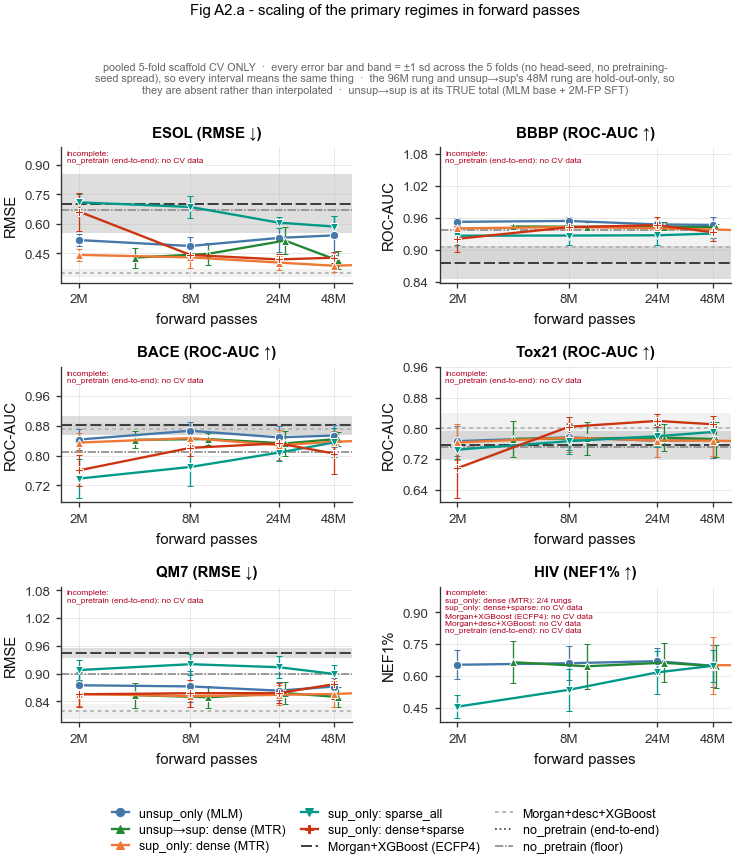

saved figA2b_scaling_unique_molecules


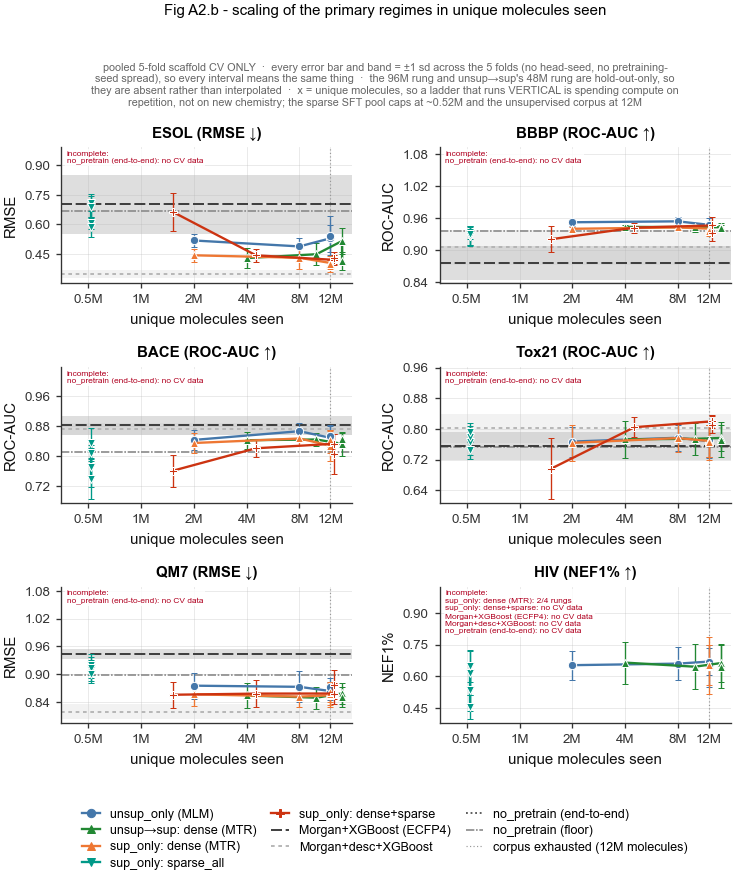


A2 change from the smallest to the largest CV-scored rung (per arm, mean over tasks):
   unsup_only (MLM)                 -0.7%   (n=6 tasks)
   unsup→sup: dense (MTR)           +0.1%   (n=6 tasks)
   sup_only: dense (MTR)            +1.9%   (n=6 tasks)
   sup_only: sparse_all            +13.4%   (n=6 tasks)
   sup_only: dense+sparse          +11.3%   (n=5 tasks)

unique molecules behind each rung (why A2.b differs from A2.a):
   unsup_only (MLM)               2M FP→2.00M mol  8M FP→8.00M mol  24M FP→12.00M mol  48M FP→12.00M mol
   unsup→sup: dense (MTR)         4M FP→4.00M mol  10M FP→10.00M mol  26M FP→14.00M mol  50M FP→14.00M mol
   sup_only: dense (MTR)          2M FP→2.00M mol  8M FP→8.00M mol  24M FP→12.00M mol  48M FP→12.00M mol  96M FP→12.00M mol
   sup_only: sparse_all           2M FP→0.52M mol  8M FP→0.52M mol  24M FP→0.52M mol  48M FP→0.52M mol
   sup_only: dense+sparse         2M FP→1.52M mol  8M FP→4.52M mol  24M FP→12.52M mol  48M FP→12.52M mol


In [7]:
# ---------- A2 · scaling ladders, on the 5-fold CV only, on BOTH scaling axes ----------
# A2.a x = forward passes (compute). A2.b x = UNIQUE MOLECULES actually seen. They are the same
# runs and the same y-values; only the x-coordinate changes -- and the two tell different stories,
# because past one epoch of a stream extra forward passes buy no new molecules. The sparse SFT
# recipes exhaust their capped pool at ~0.52M molecules, so in A2.b their ladders go VERTICAL:
# every rung above 2M FP is pure repetition. That is invisible on the compute axis.
#
# EVERY error bar here is the SAME quantity: the spread across the 5 scaffold folds. The single
# hold-out is not used and pretraining-seed replicates are deliberately ignored, because those
# replicates exist only at the 8M rung -- mixing them in would make the 8M interval mean something
# different from every other point on the same line.
A2_KEYS = ["unsup_only", "unsup2sup:dense",
           "sup_only:dense", "sup_only:sparse_all", "sup_only:dense_plus_sparse"]
# The classical anchors and the end-to-end baseline are compute-independent, so they are
# horizontal references on BOTH axes, not ladders. Greys (not their A1 bar colours) so they read as
# "the bar to clear" rather than as three more models competing with five coloured lines.
# no_pretrain_e2e has ZERO pretraining -- it is the "skip pretraining, just fine-tune" reference,
# and it populates automatically once the E1 runs land.
A2_ANCHORS = [("ecfp4",           "#333333", (0, (6, 2)),   "Morgan+XGBoost (ECFP4)"),
              ("fp_desc",         "#B3B3B3", (0, (2, 2)),   "Morgan+desc+XGBoost"),
              ("no_pretrain_e2e", "#555555", (0, (1, 1.5)), "no_pretrain (end-to-end)")]
A2_FLOOR_LS = (0, (5, 1, 1, 1))

def ladder_cv(task, key):
    """CV mean + across-fold sd per budget, seed-0 runs only. Empty frame if nothing is scored."""
    d = DF_CV[(DF_CV.wave == "climb_v2_phase2") & (DF_CV.task == task) & (DF_CV.seed == 0)]
    if key == "unsup_only":            s = d[d.regime == "unsup_only"]
    elif key.startswith("unsup2sup:"): s = d[(d.regime == "unsup2sup") & (d.recipe == key.split(":")[1])]
    else:                              s = d[(d.regime == "sup_only") & (d.recipe == key.split(":")[1])]
    s = s[~s.truncated]
    if not len(s): return s
    g = (s.groupby("budget_fp").agg(value=("value", "mean"), err=("std", "mean"))
          .reset_index().sort_values("budget_fp"))
    g["mols"] = [unique_molecules(key, b) for b in g.budget_fp]
    return g

def anchor_cv(task, key):
    """(mean, across-fold sd) for a compute-independent reference, or (nan, nan)."""
    s = DF_CV[(DF_CV.wave == "climb_v2_phase2") & (DF_CV.task == task) & (DF_CV.regime == key)]
    return (float(s.value.mean()), float(s["std"].mean())) if len(s) else (np.nan, np.nan)

# Rungs that exist in the CV eval. 96M was scored on the hold-out only, and unsup->sup has no 48M
# CV run, so both are absent here rather than silently interpolated. Stated in the caption.
BUDG = [2e6, 8e6, 24e6, 48e6]
N_RUNGS = len(BUDG)

def draw_A2(xcol, tag, xlabel, extra_note, fname):
    ncol = 2; nrow = int(np.ceil(len(CORE_TASKS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(STYLE["col2"], 2.05 * nrow)); axes = axes.ravel()
    for i, (ax, task) in enumerate(zip(axes, CORE_TASKS)):
        drew = False; gaps = []
        for key in A2_KEYS:
            g = ladder_cv(task, key)
            if not len(g):
                gaps.append(f"{rc_label(key)}: no CV data"); continue
            drew = True
            if len(g) < N_RUNGS: gaps.append(f"{rc_label(key)}: {len(g)}/{N_RUNGS} rungs")
            ax.errorbar(g[xcol], g.value, yerr=g.err, color=rc_color(key), ls=rc_ls(key),
                        lw=STYLE["lw"], marker=rc_marker(key), ms=STYLE["marker_size"], mec="white",
                        capsize=2, elinewidth=0.8, zorder=3)
        for key, col, dsh, _lab in A2_ANCHORS:   # horizontal reference + its own fold-spread band
            v, e = anchor_cv(task, key)
            if not np.isfinite(v):
                gaps.append(f"{_lab}: no CV data"); continue
            ax.axhline(v, color=col, ls=dsh, lw=1.1, zorder=2)
            if np.isfinite(e): ax.axhspan(v - e, v + e, color=col, alpha=0.16, lw=0, zorder=0)
        fl = npt_floor(DF_CV, task)
        if np.isfinite(fl): ax.axhline(fl, color=rc_color("no_pretrain"), ls=A2_FLOOR_LS, lw=1.0, zorder=1)
        if xcol == "budget_fp":
            set_fp_axis(ax, BUDG); ax.set_xlim(1.6e6, 6.0e7)
        else:
            ax.set_xscale("log"); ax.set_xlim(3.5e5, 1.6e7)
            ax.xaxis.set_major_locator(ticker.FixedLocator([5e5, 1e6, 2e6, 4e6, 8e6, 12e6]))
            ax.xaxis.set_major_formatter(ticker.FixedFormatter(
                ["0.5M", "1M", "2M", "4M", "8M", "12M"]))
            ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x", which="minor", bottom=False)
            # the corpus is only ~12M molecules, so this is where the unsupervised axis simply stops
            ax.axvline(UNSUP_CORPUS, color="#999", ls=(0, (1, 2)), lw=0.7, zorder=1)
        ax.set_title(ttitle(task, oneline=True), pad=6); ax.set_xlabel(xlabel)
        ax.set_ylabel(re.sub(r"\s*[↑↓]\s*$", "", mlabel(task)))   # arrow lives in the title
        label_all_yticks(ax)
        # A line that simply stops short is indistinguishable from a line that plateaued. Name the gaps.
        if gaps:
            ax.set_ylim(top=ax.get_ylim()[1] * (1.06 + 0.07 * int(np.ceil(len(gaps) / 2))))
            ax.text(0.02, 0.98, "incomplete:\n" + "\n".join(gaps), transform=ax.transAxes,
                    ha="left", va="top", fontsize=STYLE["fs_annot"] - 2, color="#B00020",
                    linespacing=1.2, bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.0))
        if not drew: no_data_watermark(ax, "no CV-scored runs")
    for ax in axes[len(CORE_TASKS):]: ax.axis("off")

    handles = [plt.Line2D([], [], color=rc_color(k), marker=rc_marker(k), ls=rc_ls(k), label=rc_label(k))
               for k in A2_KEYS]
    handles += [plt.Line2D([], [], color=c, ls=d, lw=1.1, label=lab) for _, c, d, lab in A2_ANCHORS]
    handles += [plt.Line2D([], [], color=rc_color("no_pretrain"), ls=A2_FLOOR_LS, lw=1.0,
                           label="no_pretrain (floor)")]
    if xcol == "mols":
        handles += [plt.Line2D([], [], color="#999", ls=(0, (1, 2)), lw=0.7,
                               label="corpus exhausted (12M molecules)")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3,
               fontsize=STYLE["fs_legend"], columnspacing=1.2)
    fig.suptitle(f"Fig {tag} - scaling of the primary regimes in {xlabel}",
                 fontsize=STYLE["fs_title"], y=1.075)
    note = ("pooled 5-fold scaffold CV ONLY  ·  every error bar and band = ±1 sd across the 5 folds "
            "(no head-seed, no pretraining-seed spread), so every interval means the same thing  ·  "
            "the 96M rung and unsup→sup's 48M rung are hold-out-only, so they are absent rather "
            "than interpolated  ·  " + extra_note)
    fig.text(0.5, 0.995, "\n".join(_tw.wrap(note, 120)), ha="center", va="top",
             fontsize=STYLE["fs_annot"] - 0.5, color="#666")
    fig.subplots_adjust(top=0.88, bottom=0.10, hspace=0.62, wspace=0.30)
    save_fig(fig, fname); plt.show()

draw_A2("budget_fp", "A2.a", "forward passes",
        "unsup→sup is at its TRUE total (MLM base + 2M-FP SFT)",
        "figA2a_scaling_forward_passes")
draw_A2("mols", "A2.b", "unique molecules seen",
        "x = unique molecules, so a ladder that runs VERTICAL is spending compute on repetition, "
        "not on new chemistry; the sparse SFT pool caps at ~0.52M and the unsupervised corpus at 12M",
        "figA2b_scaling_unique_molecules")

print(f"\nA2 change from the smallest to the largest CV-scored rung (per arm, mean over tasks):")
for key in A2_KEYS:
    spans = [100 * lift(g.value.iloc[-1], t, g.value.iloc[0])
             for t in CORE_TASKS for g in [ladder_cv(t, key)] if len(g) >= 2]
    if spans: print(f"   {rc_label(key):<30} {np.mean(spans):+6.1f}%   (n={len(spans)} tasks)")

print("\nunique molecules behind each rung (why A2.b differs from A2.a):")
for key in A2_KEYS:
    g = ladder_cv("ESOL", key)
    if len(g):
        print(f"   {rc_label(key):<30} " +
              "  ".join(f"{b/1e6:.0f}M FP→{m/1e6:.2f}M mol" for b, m in zip(g.budget_fp, g.mols)))

## B1p1 · Does pretraining help small datasets more — and through which mechanism?

Frozen probes on the 8 M encoders, trained on 100 → 3 000 → all labels (3 subsample draws × 3 head
seeds per point).

- **Solid = test, dashed = train, same colour per regime.** Test alone cannot tell "the head cannot
  *fit* this many labels" from "it fits and fails to *generalize*"; the train–test gap can.
- A large gap at small *N* → data-limited (fits, does not generalize). Both curves low → the frozen
  representation is capacity-limited.

Train and test must be the *same* metric to be comparable, so HIV is scored by ROC-AUC here rather
than by the NEF1% used elsewhere (there is no NEF1%-on-train).

saved figB1p1_label_efficiency_train_test


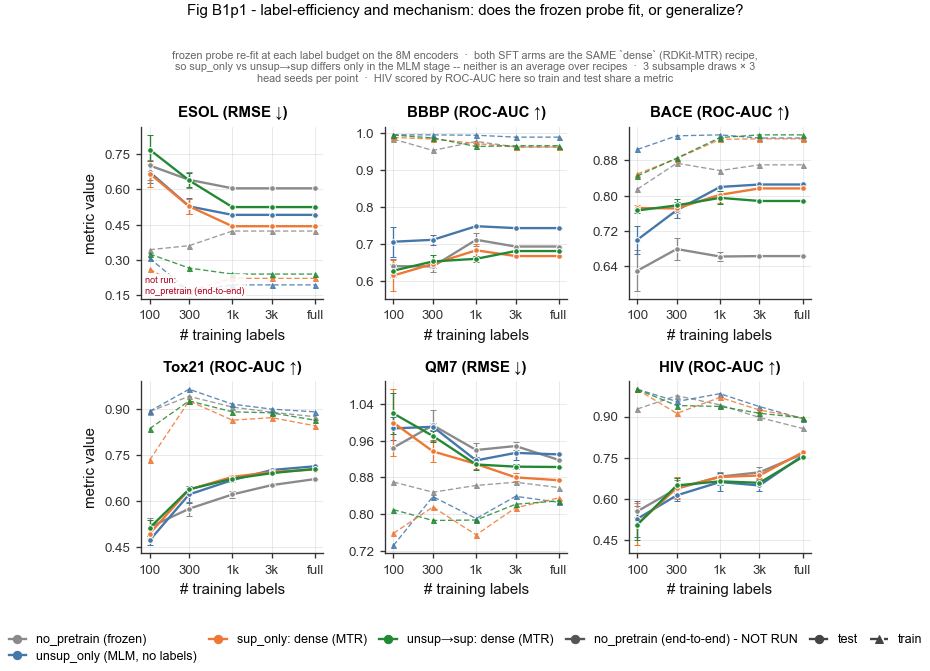


B1p1 mean |train - test| gap, smallest vs largest label budget:
   no_pretrain (frozen)           n=100: 0.286   full: 0.169
   unsup_only (MLM, no labels)    n=100: 0.335   full: 0.178
   sup_only: dense (MTR)          n=100: 0.305   full: 0.156
   unsup→sup: dense (MTR)         n=100: 0.319   full: 0.183
   no_pretrain (end-to-end)       n=100: nan   full: nan


In [8]:
# ---------- B1p1 · label-efficiency, train vs test ----------
LE="figure_data/climb_v2_labeleff_v2"
# Directory prefix -> (label, colour). The labels name the EXACT encoder behind each series
# (scripts/b1_replicates_v2.sh), because "sup_only" and "unsup→sup" are five-recipe families
# elsewhere in this notebook and an unqualified label here would read as an average over them.
# It is not an average: both SFT arms are the `dense` (RDKit-MTR) recipe at the 8M rung, chosen so
# they differ ONLY in whether an MLM stage came first. Colours match A1/A2 for the same models.
#   random    -> climb_v2_phase2/random_baseline_00   (random init, frozen)
#   unsup     -> climb_v2_phase2/unsup_8M             (MLM only -- no supervised labels at all)
#   sup       -> climb_v2_phase2/skip_dense_8M        (random init -> MTR on descriptors)
#   unsup2sup -> climb_v2_phase2/u2s_dense_from8M     (MLM 8M -> MTR on descriptors)
LE_REGIMES=[("random","no_pretrain (frozen)",rc_color("no_pretrain")),
            ("unsup","unsup_only (MLM, no labels)",rc_color("unsup_only")),
            ("sup","sup_only: dense (MTR)",rc_color("sup_only:dense")),
            ("unsup2sup","unsup→sup: dense (MTR)",rc_color("unsup2sup:dense")),
            # Declared so its absence is visible. It cannot come from this wave: every series
            # above is a frozen probe re-fit at each label budget, whereas the end-to-end arm
            # needs the ENCODER re-fine-tuned at each budget -- a separate sweep that has not
            # been run (scripts/b1_replicates_v2.sh says so explicitly).
            ("e2e","no_pretrain (end-to-end)",rc_color("no_pretrain_e2e"))]
LE_SIZES=[("100",100),("300",300),("1000",1000),("3000",3000),("0",10000)]

_LE={}
for f in glob.glob(f"{LE}/*/moleculenet/moleculenet_summary.csv"):
    t=f.split("/")[-3].split("_"); size=t[-2].replace("n",""); reg="_".join(t[:-2])
    for _,r in pd.read_csv(f).query("head_seed=='MEAN'").iterrows():
        mm=str(r.main_metric)
        if   mm in ("rmse","roc_auc"): kind="test"
        elif mm.endswith("_train"):    kind="train"
        else: continue                            # nef1 etc: no train counterpart, skip
        _LE.setdefault((reg,size,r.dataset,kind),[]).append(r.main_value)
def le(reg,size,task,kind="test"):
    v=_LE.get((reg,size,task,kind),[])
    return (float(np.mean(v)), float(np.std(v)) if len(v)>1 else 0.0) if v else (np.nan,0.0)

ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.4*nrow)); axes=axes.ravel()
xs=[x for _,x in LE_SIZES]
_le_missing=set()
for ax,task in zip(axes,CORE_TASKS):
    drew=False
    for reg,_lab,c in LE_REGIMES:
        te=[le(reg,s,task,"test")[0]  for s,_ in LE_SIZES]
        tr=[le(reg,s,task,"train")[0] for s,_ in LE_SIZES]
        ee=[le(reg,s,task,"test")[1]  for s,_ in LE_SIZES]
        if all(not np.isfinite(v) for v in te): _le_missing.add(_lab); continue
        drew=True
        ax.errorbar(xs,te,yerr=ee,color=c,marker="o",ms=3.4,lw=STYLE["lw"],mec="white",
                    capsize=2,elinewidth=0.8,zorder=3)
        ax.plot(xs,tr,color=c,marker="^",ms=3.0,lw=STYLE["lw_thin"],ls=(0,(4,2)),alpha=0.85,zorder=2)
    # HIV is scored by ROC-AUC in this figure (train has no NEF1% counterpart) -- the title has
    # to say so, or it silently contradicts the axis.
    _t=("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True))
    ax.set_xscale("log"); ax.set_title(_t,pad=6)
    ax.set_xlabel("# training labels")
    ax.xaxis.set_major_locator(ticker.FixedLocator(xs))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter(["100","300","1k","3k","full"]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,"label-efficiency sweep missing")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
if _le_missing:                     # a legend entry with no line is a claim; say it is missing
    axes[0].text(0.02,0.02,"not run:\n"+"\n".join(sorted(_le_missing)),transform=axes[0].transAxes,
                 ha="left",va="bottom",fontsize=STYLE["fs_annot"]-1.5,color="#B00020",
                 linespacing=1.25,bbox=dict(fc="white",ec="none",alpha=0.85,pad=1.0))
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")

reg_h=[plt.Line2D([],[],color=c,marker="o",
                  label=lab+(" - NOT RUN" if lab in _le_missing else "")) for _,lab,c in LE_REGIMES]
sty_h=[plt.Line2D([],[],color="#444",marker="o",ls="-",label="test"),
       plt.Line2D([],[],color="#444",marker="^",ls=(0,(4,2)),label="train")]
fig.legend(handles=reg_h+sty_h,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=6,
           fontsize=STYLE["fs_legend"])
fig.suptitle("Fig B1p1 - label-efficiency and mechanism: does the frozen probe fit, or generalize?",
             fontsize=STYLE["fs_title"],y=1.075)
_b1note=("frozen probe re-fit at each label budget on the 8M encoders  ·  both SFT arms are the "
         "SAME `dense` (RDKit-MTR) recipe, so sup_only vs unsup→sup differs only in the MLM stage "
         "-- neither is an average over recipes  ·  3 subsample draws × 3 head seeds per point  ·  "
         "HIV scored by ROC-AUC here so train and test share a metric")
fig.text(0.5,0.995,"\n".join(_tw.wrap(_b1note,120)),
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.86,bottom=0.12,hspace=0.48,wspace=0.34)
save_fig(fig,"figB1p1_label_efficiency_train_test"); plt.show()

print("\nB1p1 mean |train - test| gap, smallest vs largest label budget:")
for reg,lab,_ in LE_REGIMES:
    out=[]
    for size in ("100","0"):
        g=[abs(le(reg,size,t,"train")[0]-le(reg,size,t,"test")[0]) for t in CORE_TASKS]
        g=[v for v in g if np.isfinite(v)]
        out.append(np.mean(g) if g else np.nan)
    print(f"   {lab:<30} n=100: {out[0]:.3f}   full: {out[1]:.3f}")

## E1 · H5 — is the `sup_only` / `unsup_only` ordering a frozen-probe artifact?

Every other figure scores a **frozen** encoder. Two things could be artifacts of that probe:

- the pretraining ladder looks **flat** — maybe the head is too weak to exploit a better encoder;
- `sup_only` and `unsup_only` sit in a particular **order** — maybe unfreezing reverses it.

The second is H5, and it needs *both* regimes in *both* conditions: a single frozen line and a
single fine-tuned line have nothing to flip against. So each task carries four series —
`unsup_only` and `sup_only` (`dense`, the best recipe by mean lift in A1), each frozen and
fine-tuned end-to-end, at matched 2M/8M/24M budgets.

- **(a)** the ladders. Open marker + dashed = frozen, filled + solid = fine-tuned.
- **(b)** the ordering test at the matched 8M budget: one segment per regime, frozen → fine-tuned.
  The two regimes are plotted side by side on a shared y-axis, so **a crossing between the
  segments is an ordering flip** and is impossible to miss.

Two cautions the panels carry in their caption. HIV is scored by ROC-AUC here, not the NEF1% used
elsewhere, because that is what the fine-tuning harness computes — train and test must be the same
metric on both sides of the comparison. And the two error bars are *not* the same quantity: a
frozen probe's only randomness is the head (the encoder is fixed, so its features are
deterministic), while a fine-tuning seed re-randomises the head **and** the whole encoder
optimisation.

saved figE1_H5_eval_ceiling


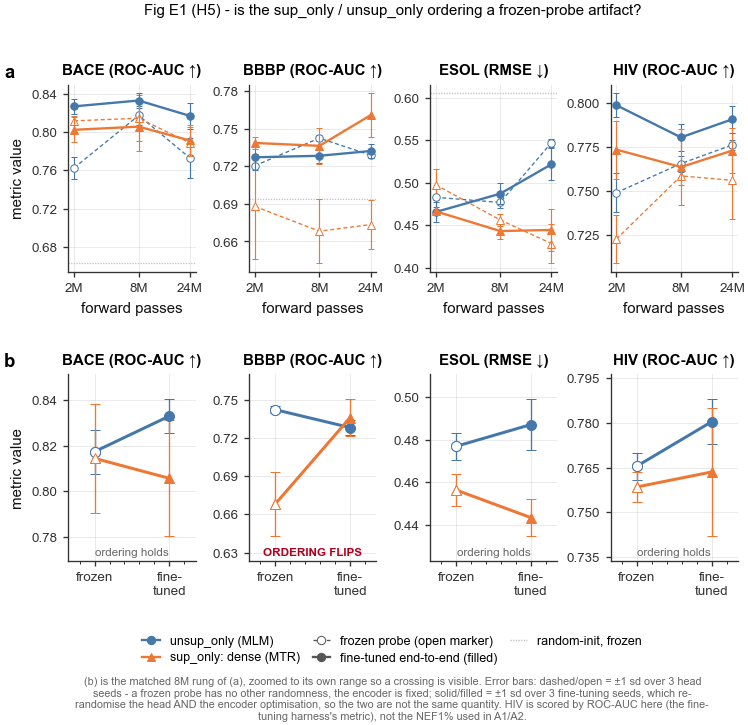


E1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise it must clear:
   unsup_only (MLM)       BACE  frozen=0.0546 (3.9x head-seed sd) finetuned=0.0160  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       BBBP  frozen=0.0220 (11.6x head-seed sd) finetuned=0.0050  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       ESOL  frozen=0.0700 (9.3x head-seed sd) finetuned=0.0560  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       HIV   frozen=0.0271 (4.4x head-seed sd) finetuned=0.0183  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BACE  frozen=0.0257 (1.7x head-seed sd) finetuned=0.0144  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BBBP  frozen=0.0198 (0.7x head-seed sd) finetuned=0.0244  -> fine-tuning SEPARATES them: the probe may be the ceiling
   sup_only: dense (MTR)  ESOL  frozen

In [9]:
# ---------- E1 · H5: regime-split eval ceiling ----------
# The first version of this figure plotted ONE frozen and ONE fine-tuned line, both from the
# unsup_only ladder. That answers a ladder-SHAPE question; it cannot answer H5, which is about the
# ORDERING of two regimes. sup_only is fine-tuned by scripts/run_e1_sup_gpu.sh into a separate
# output dir, merged here, so the 48 unsup fine-tunes are not redone.
CEIL     = DATA_ROOT/"_eval_ceiling"/"eval_ceiling.csv"
CEIL_SUP = DATA_ROOT/"_eval_ceiling_sup"/"eval_ceiling.csv"
E1_SUP_RECIPE = "dense"          # best sup_only recipe by mean lift in A1

def _regime_of(run_id):
    if run_id.startswith("random_baseline"): return "no_pretrain"
    if run_id.startswith("unsup_"):          return "unsup_only"
    m=re.match(r"skip_(.+)_\d+M$",run_id)
    return f"sup_only:{m[1]}" if m else None

_parts=[pd.read_csv(q) for q in (CEIL,CEIL_SUP) if q.exists()]
C = pd.concat(_parts,ignore_index=True) if _parts else pd.DataFrame()
if len(C):
    if "seed" not in C.columns: C["seed"]=0
    C["regime"]=C.run_id.map(_regime_of)

E1_REGIMES=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}")
            if len(C) and k in set(C.regime)]
_E1_PENDING=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}") if k not in E1_REGIMES]

if not len(C):
    fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6))
    no_data_watermark(ax,"run scripts/run_e1_gpu.sh")
    fig.suptitle("Fig E1 (H5) [NO DATA]",fontsize=STYLE["fs_title"])
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()
else:
    nseed=C.seed.nunique()
    e1_tasks=[t for t in ("BACE","BBBP","ESOL","HIV") if t in set(C.task)]

    # Frozen values come from the run summaries PER HEAD SEED, not from the cached CSV: the CSV
    # collapsed them to a single MEAN and copied it onto every seed row, so its spread was zero.
    # Reading the summaries also keeps E1 on the same scorer as A1/A2.
    def _frozen_seeds(run_id,task):
        f=DATA_ROOT/"climb_v2_phase2"/run_id/"moleculenet"/"moleculenet_summary.csv"
        if not f.exists(): return np.array([])
        d=pd.read_csv(f)
        d=d[(d.dataset==task)&(d.main_metric.isin(["roc_auc","rmse"]))     # not _train, not nef1
            &(~d.head_seed.astype(str).isin(["MEAN","STD"]))]
        return d.main_value.values.astype(float)

    def e1_points(regime,task):
        """-> tidy frame: one row per budget with frozen/fine-tuned mean and sd."""
        s=C[(C.regime==regime)&(C.task==task)&(C.budget>0)]
        rows=[]
        for (rid,b),g in s.groupby(["run_id","budget"]):
            fz=_frozen_seeds(rid,task)
            rows.append(dict(run_id=rid,budget=b,
                             fz=(np.mean(fz) if len(fz) else np.nan),
                             fz_sd=(np.std(fz,ddof=1) if len(fz)>1 else np.nan),
                             ft=g.finetune.mean(),
                             ft_sd=(g.finetune.std() if len(g)>1 else np.nan)))
        return pd.DataFrame(rows).sort_values("budget") if rows else pd.DataFrame()

    def e1_random(task,col):
        s=C[(C.regime=="no_pretrain")&(C.task==task)]
        return s[col].mean() if len(s) else np.nan

    E1_STYLE={k:dict(c=rc_color(k),m=rc_marker(k) or "o") for k in E1_REGIMES}
    ncol=len(e1_tasks)
    fig,axes=plt.subplots(2,ncol,figsize=(STYLE["col2"],6.2),
                          gridspec_kw=dict(height_ratios=[1,1],hspace=0.55,wspace=0.42))
    axes=np.atleast_2d(axes)

    # ---------- (a) the ladders: 2 regimes x {frozen, fine-tuned} ----------
    for j,task in enumerate(e1_tasks):
        ax=axes[0,j]
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            st=E1_STYLE[k]
            ax.errorbar(d.budget,d.fz,yerr=d.fz_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls=(0,(3,2)),lw=STYLE["lw_thin"],mfc="white",ms=4.5,
                        capsize=2,elinewidth=0.7,zorder=3)
            ax.errorbar(d.budget,d.ft,yerr=d.ft_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls="-",lw=STYLE["lw"],ms=4.5,capsize=2,elinewidth=0.7,zorder=4)
        _rf=e1_random(task,"frozen")
        if np.isfinite(_rf):
            ax.axhline(_rf,ls=(0,(1,1)),color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
        _bud=sorted(C[(C.task==task)&(C.budget>0)].budget.unique())
        if _bud: set_fp_axis(ax,_bud)
        ax.set_xlabel("forward passes")
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
    axes[0,0].set_ylabel("metric value")
    panel_tag(axes[0,0],"a",dx=-0.42)

    # ---------- (b) the H5 ordering test at the matched budget ----------
    _flips=[]
    for j,task in enumerate(e1_tasks):
        ax=axes[1,j]
        hb=TASKS[task]["higher_better"] if task!="HIV" else True   # ROC-AUC here, so higher=better
        vals={}
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            r=d.iloc[(d.budget-BUDGET_FP[MATCHED_BUDGET]).abs().argsort().iloc[0]]
            st=E1_STYLE[k]
            ax.errorbar([0,1],[r.fz,r.ft],
                        yerr=[0 if not np.isfinite(r.fz_sd) else r.fz_sd,
                              0 if not np.isfinite(r.ft_sd) else r.ft_sd],
                        color=st["c"],marker=st["m"],ms=6,lw=STYLE["lw"]+0.4,
                        capsize=3,elinewidth=0.8,zorder=3)
            ax.plot([0],[r.fz],marker=st["m"],ms=6,color=st["c"],mfc="white",zorder=4)  # open=frozen
            vals[k]=(r.fz,r.ft)
        ax.set_xlim(-0.35,1.35); ax.set_xticks([0,1])
        ax.set_xticklabels(["frozen","fine-\ntuned"])
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
        # Deliberately NOT sharing y with the ladder above: on the ladder's range the two segments
        # sit almost on top of each other and a crossing is invisible, which is the one thing this
        # panel exists to show. It is zoomed to its own data; the caption says so.
        ax.margins(y=0.18)
        # Does the ordering survive? Compare the sign of (unsup - sup) in each condition.
        if len(vals)==2:
            u,s_=vals["unsup_only"],vals[f"sup_only:{E1_SUP_RECIPE}"]
            better=lambda a,b:(a>b) if hb else (a<b)
            fz_u_wins,ft_u_wins=better(u[0],s_[0]),better(u[1],s_[1])
            flip = fz_u_wins!=ft_u_wins
            _flips.append((task,fz_u_wins,ft_u_wins,flip))
            ax.text(0.5,0.02,("ORDERING FLIPS" if flip else "ordering holds"),
                    transform=ax.transAxes,ha="center",va="bottom",
                    fontsize=STYLE["fs_annot"],fontweight=("bold" if flip else "normal"),
                    color=("#B00020" if flip else "#666"))
    axes[1,0].set_ylabel("metric value")
    panel_tag(axes[1,0],"b",dx=-0.42)

    handles=[plt.Line2D([],[],color=E1_STYLE[k]["c"],marker=E1_STYLE[k]["m"],ls="-",
                        label=rc_label(k)) for k in E1_REGIMES]
    handles+=[plt.Line2D([],[],color="#555",marker="o",mfc="white",ls=(0,(3,2)),
                         lw=STYLE["lw_thin"],label="frozen probe (open marker)"),
              plt.Line2D([],[],color="#555",marker="o",ls="-",label="fine-tuned end-to-end (filled)"),
              plt.Line2D([],[],color=PALETTE["grey2"],ls=(0,(1,1)),lw=STYLE["lw_thin"],
                         label="random-init, frozen")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.155),ncol=3,
               fontsize=STYLE["fs_legend"])
    fig.suptitle("Fig E1 (H5) - is the sup_only / unsup_only ordering a frozen-probe artifact?",
                 fontsize=STYLE["fs_title"],y=0.99)
    # One figure-level pending note: per-panel boxes landed on the data in all four panels, and
    # the missing arm is missing everywhere, so saying it four times bought nothing.
    if _E1_PENDING:
        fig.text(0.5,0.955,"PENDING - "+", ".join(rc_label(k) for k in _E1_PENDING)
                 +" not fine-tuned yet, so (b) cannot test the ordering",
                 ha="center",va="top",fontsize=STYLE["fs_annot"],color="#B00020",fontweight="bold")
    _fzn=max([len(_frozen_seeds(r,e1_tasks[0])) for r in C.run_id.unique()]+[0])
    _note=(f"(b) is the matched {MATCHED_BUDGET} rung of (a), zoomed to its own range so a "
           f"crossing is visible. Error bars: dashed/open = ±1 sd over "
           f"{_fzn} head seeds - a frozen probe has no other randomness, the encoder is fixed; "
           f"solid/filled = ±1 sd over {nseed} fine-tuning seeds, which re-randomise the head AND "
           f"the encoder optimisation, so the two are not the same quantity. HIV is scored by "
           f"ROC-AUC here (the fine-tuning harness's metric), not the NEF1% used in A1/A2.")
    fig.subplots_adjust(top=0.88,bottom=0.24)
    fig.text(0.5,0.085,"\n".join(_tw.wrap(_note,132)),ha="center",va="top",
             fontsize=STYLE["fs_annot"]-0.5,color="#666")
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()

    # ---------- printed readouts ----------
    if _E1_PENDING:
        print("E1: STILL PENDING -> "+", ".join(rc_label(k) for k in _E1_PENDING)
              +"  (run scripts/run_e1_sup_gpu.sh)")
    print(f"\nE1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise "
          f"it must clear:")
    for k in E1_REGIMES:
        for task in e1_tasks:
            d=e1_points(k,task)
            if len(d)<2: continue
            noise=np.nanmean(d.fz_sd.values)
            dz,dt=d.fz.max()-d.fz.min(),d.ft.max()-d.ft.min()
            verdict=("fine-tuning COMPRESSES it: the probe was NOT the ceiling" if dt<dz
                     else "fine-tuning SEPARATES them: the probe may be the ceiling")
            print(f"   {rc_label(k):<22} {task:<5} frozen={dz:.4f} ({dz/noise:.1f}x head-seed sd) "
                  f"finetuned={dt:.4f}  -> {verdict}")
    if _flips:
        print(f"\nE1 (b) H5 ordering at {MATCHED_BUDGET} (does unsup_only beat sup_only?):")
        for task,fz_u,ft_u,flip in _flips:
            print(f"   {task:<5} frozen: {'unsup' if fz_u else 'sup'} ahead   "
                  f"fine-tuned: {'unsup' if ft_u else 'sup'} ahead   "
                  f"-> {'FLIPS' if flip else 'holds'}")
        nf=sum(f for _,_,_,f in _flips)
        print(f"   {nf}/{len(_flips)} tasks flip. "
              +("The frozen ordering is NOT preserved under fine-tuning." if nf>len(_flips)/2
                else "The frozen ordering largely survives fine-tuning, so it is not a probe artifact."))

## B2 · If we pretrain on a *garbled* objective, do the benefits survive?

The E13 control holds objective, data volume, compute, schedule and model fixed and removes only
the **chemical content**:

- `corrupt_mlm` — token order permuted inside each sequence (SMILES grammar destroyed, token
  distribution and mask rate preserved).
- `corrupt_mtr` — descriptor targets permuted across the batch (molecule→descriptor mapping
  destroyed, target distribution untouched).

How to read it: *corrupted ≈ no_pretrain, real > both* ⇒ pretraining adds **information**.
*corrupted ≈ real* ⇒ the gain comes from the objective's structure (initialization / regularization),
not from chemistry.

saved figB2_corrupted_control


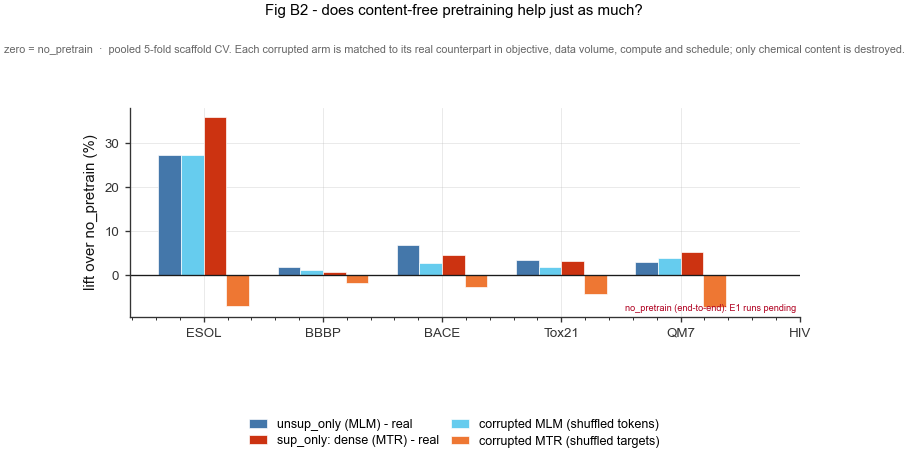

B2 mean lift over no_pretrain across the core tasks (pooled 5-fold scaffold CV):
   unsup_only (MLM) - real                    +8.4%  (n=5)
   corrupted MLM (shuffled tokens)            +7.3%  (n=5)
   sup_only: dense (MTR) - real               +9.9%  (n=5)
   corrupted MTR (shuffled targets)           -4.6%  (n=5)

per-task lift (%), to expose any single task driving the mean:
       unsup_only (MLM) - real  corrupted MLM (shuffled tokens)  sup_only: dense (MTR) - real  corrupted MTR (shuffled targets)
ESOL                      27.2                             27.2                          35.8                              -7.2
BBBP                       1.8                              1.1                           0.6                              -1.8
BACE                       6.8                              2.6                           4.4                              -2.7
Tox21                      3.3                              1.7                           3.2              

In [10]:
# ---------- B2 · corrupted-pretraining control ----------
# Colour encodes the PAIR, lightness encodes real-vs-corrupted: dark blue / light blue for the MLM
# pair, dark red / light orange for the MTR pair. All four come from the shared PALETTE, so the
# figure still reads as part of the same set even though the pairing is B2-specific.
B2_SERIES=[("unsup_only",     "unsup_only (MLM) - real",          PALETTE["blue"]),
           ("corrupt_mlm",    "corrupted MLM (shuffled tokens)",  PALETTE["cyan"]),
           ("sup_only:dense", "sup_only: dense (MTR) - real",     PALETTE["red"]),
           ("corrupt_mtr",    "corrupted MTR (shuffled targets)", PALETTE["orange"])]

# PREFER the 5-fold CV: on the single hold-out this panel is scored on 113-204 molecules per task
# and HIV's NEF1% comes off the top 1% of ~4.1k molecules (~41 molecules), which is why the HIV
# bars swing wildly there. The corrupted encoders have not been CV-scored yet, so the figure falls
# back to the hold-out and says so on its face rather than quietly using the weak split.
_b2_have_cv=all(len(arm_rows(DF_CV,"ESOL",k)) for k,_,_ in B2_SERIES)
B2_DF   = DF_CV if _b2_have_cv else DF
B2_SCHEME=("pooled 5-fold scaffold CV" if _b2_have_cv else
           "single scaffold hold-out (113-204 test molecules) - CV PENDING for the corrupted arms")
_have_b2=any(len(arm_rows(B2_DF,"ESOL",k)) for k,_,_ in B2_SERIES if k.startswith("corrupt"))

fig,ax=plt.subplots(figsize=(STYLE["col2"],2.9))
x=np.arange(len(CORE_TASKS)); w=0.19
for i,(key,lab,c) in enumerate(B2_SERIES):
    ys=[100*lift(arm_value(B2_DF,t,key),t,npt_floor(B2_DF,t)) for t in CORE_TASKS]
    ax.bar(x+(i-1.5)*w,ys,width=w,color=c,edgecolor="white",lw=0.4,label=lab)
ax.axhline(0,color=PALETTE["black"],lw=0.8)
# "Skip pretraining and just fine-tune" is the reference that makes the corrupted/real contrast
# actionable: a corrupted arm that clears no_pretrain but not this one has bought nothing real.
_e2e=[100*lift(arm_value(B2_DF,t,"no_pretrain_e2e"),t,npt_floor(B2_DF,t)) for t in CORE_TASKS]
if any(np.isfinite(v) for v in _e2e):
    for xi,v in zip(x,_e2e):
        if np.isfinite(v):
            ax.plot([xi-0.5,xi+0.5],[v,v],color=rc_color("no_pretrain_e2e"),ls=(0,(1,1.5)),lw=1.3,
                    zorder=5,solid_capstyle="butt")
    _e2e_h=[plt.Line2D([],[],color=rc_color("no_pretrain_e2e"),ls=(0,(1,1.5)),lw=1.3,
                       label="no_pretrain (end-to-end)")]
else:
    _e2e_h=[]
    ax.text(0.995,0.02,"no_pretrain (end-to-end): E1 runs pending",transform=ax.transAxes,
            ha="right",va="bottom",fontsize=STYLE["fs_annot"]-1.5,color="#B00020")
ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS])
ax.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax)
if not _have_b2:
    ax.text(0.5,1.02,"CORRUPTED ARMS NOT YET AVAILABLE — corrupt_mlm_8M / corrupt_mtr_8M still training",
            transform=ax.transAxes,ha="center",va="bottom",fontsize=STYLE["fs_annot"],
            color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",fc="#FCE8E8",ec="#B00020",lw=0.8))
elif not _b2_have_cv:
    ax.text(0.5,1.02,"SCHEME FALLBACK — corrupted arms have no 5-fold CV eval yet, so this panel is "
            "on the small single hold-out; HIV especially is unreliable here",
            transform=ax.transAxes,ha="center",va="bottom",fontsize=STYLE["fs_annot"]-1,
            color="#B00020",bbox=dict(boxstyle="round,pad=0.3",fc="#FCE8E8",ec="#B00020",lw=0.8))
# Column-major fill: this order puts MLM-real top-left, MLM-corrupted top-right, MTR-real
# bottom-left, MTR-corrupted bottom-right, so each pair is read down a column... no: matplotlib
# fills column-first, so the handles are reordered here to land as [TL, TR / BL, BR].
_h,_l=ax.get_legend_handles_labels()
_ord=[0,2,1,3]                       # -> col0 = (MLM real, MTR real); col1 = (MLM corr, MTR corr)
fig.legend(handles=[_h[i] for i in _ord]+_e2e_h,labels=[_l[i] for i in _ord]+[h.get_label() for h in _e2e_h],
           loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig B2 - does content-free pretraining help just as much?",
             fontsize=STYLE["fs_title"],y=1.18)
fig.text(0.5,1.06,f"zero = no_pretrain  ·  {B2_SCHEME}. Each corrupted arm is matched to its real "
         "counterpart in objective, data volume, compute and schedule; only chemical content is destroyed.",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(bottom=0.28)
save_fig(fig,"figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER")); plt.show()

if _have_b2:
    print(f"B2 mean lift over no_pretrain across the core tasks ({B2_SCHEME}):")
    for key,lab,_ in B2_SERIES:
        ls=[lift(arm_value(B2_DF,t,key),t,npt_floor(B2_DF,t)) for t in CORE_TASKS]
        ls=[v for v in ls if np.isfinite(v)]
        if ls: print(f"   {lab:<40} {100*np.mean(ls):+6.1f}%  (n={len(ls)})")
    print("\nper-task lift (%), to expose any single task driving the mean:")
    print(pd.DataFrame({lab:[100*lift(arm_value(B2_DF,t,key),t,npt_floor(B2_DF,t)) for t in CORE_TASKS]
                        for key,lab,_ in B2_SERIES},index=CORE_TASKS).round(1).to_string())
else:
    print("B2: no corrupted-control data yet. Expected runs: corrupt_mlm_8M, corrupt_mtr_8M "
          "(8M FP each, matched to unsup_8M / skip_dense_8M).")

## C1J1 · Which supervised pretraining data helps, how much, and does it track chemistry?

One figure, three panels, because the three questions share the same runs and plotting them apart
duplicated the same numbers twice:

- **(a)** Average lift over `no_pretrain` per arm — *which SFT label type is most beneficial?*
- **(b)** The same lift resolved per evaluation task — *where does each family transfer to?*
- **(c)** The **H10 test**: does that transfer track chemical similarity between the SFT family and
  the evaluation task? Each point is one arm × task cell from (b). x is mean max ECFP4 **Tanimoto
  similarity** — further right means the eval molecules are *more* similar to what the arm trained
  on. A positive slope would support content-similarity-driven transfer.

All arms are `unsup→sup` from one shared MLM base, evaluated identically. This is the **deduped**
wave: the SFT blocklist drops 34 301 eval molecules, so no arm trains on eval-test molecules and
(c) measures genuine near-neighbour chemistry rather than memorization.

   floor differs between waves on ESOL: dedup=0.6102 vs phase2=0.6437 (5.2%) - each arm uses its own wave's floor
   floor differs between waves on BBBP: dedup=0.6951 vs phase2=0.7241 (4.0%) - each arm uses its own wave's floor
   floor differs between waves on BACE: dedup=0.6787 vs phase2=0.6869 (1.2%) - each arm uses its own wave's floor
   floor differs between waves on Tox21: dedup=0.6707 vs phase2=0.6762 (0.8%) - each arm uses its own wave's floor
   floor differs between waves on HIV: dedup=0.4180 vs phase2=0.4841 (13.7%) - each arm uses its own wave's floor


saved figC1J1_sft_family_transfer


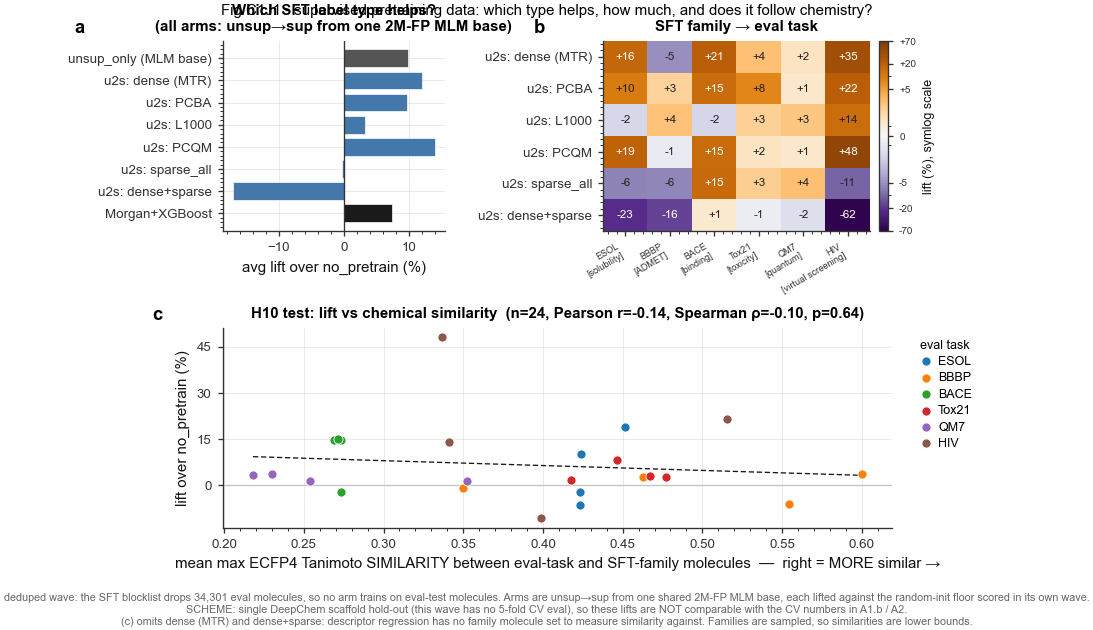

C1J1 (a) mean lift over no_pretrain:
   unsup_only (MLM base)      +9.8%
   u2s: dense (MTR)          +12.1%
   u2s: PCBA                  +9.7%
   u2s: L1000                 +3.2%
   u2s: PCQM                 +14.0%
   u2s: sparse_all            -0.3%
   u2s: dense+sparse         -17.1%
   Morgan+XGBoost             +7.4%

NOTE - C1J1 vs A1 are different models despite the shared recipe names:
   C1J1 'u2s: dense+sparse' = climb_v2_ablation_dedup/seq_dense_plus_sparse (unsup→sup from a 2M MLM base, single hold-out)
   A1   'sup_only: dense+sparse' = climb_v2_phase2/skip_dense_plus_sparse_8M (random init, 8M SFT, A1.b uses 5-fold CV)
   Different regime, budget, wave AND eval scheme -- their rankings need not agree.

C1J1 (c) H10: n=24 arm x task cells, Pearson r=-0.138, Spearman rho=-0.099 (p=0.645), similarity range 0.22-0.60
   within ESOL  : rho=+0.80 (n=4)
   within BBBP  : rho=+0.40 (n=4)
   within BACE  : rho=-0.40 (n=4)
   within Tox21 : rho=+0.20 (n=4)
   within QM7   : rho=-0

In [11]:
# ---------- C1J1 · SFT-family ablation + transfer matrix + the H10 similarity test ----------
ABL="climb_v2_ablation_dedup"
ABL_ARMS=["seq_mtr","seq_pcba","seq_l1000","seq_pcqm","seq_sparse_all","seq_dense_plus_sparse"]
# Every arm here is unsup->sup warm-started from ONE 2M-FP MLM base, in the ablation wave, scored
# on the single scaffold hold-out. The bare recipe names ("dense+sparse") are also A1/A2 arm names
# for a DIFFERENT model -- sup_only, random init, 8M budget, phase-2 wave -- so they are prefixed
# here. Without the prefix the two figures look like they contradict each other when they are
# simply reporting different models.
ABL_LABEL={"seq_mtr":"u2s: dense (MTR)","seq_pcba":"u2s: PCBA","seq_l1000":"u2s: L1000",
           "seq_pcqm":"u2s: PCQM","seq_sparse_all":"u2s: sparse_all",
           "seq_dense_plus_sparse":"u2s: dense+sparse"}
# The ablation arms warm-start from climb_v2_phase2/unsup_2M, so THAT is the MLM base to show as
# the reference row -- not the round-1 unsup_only run the earlier version of this figure used.
BASE_RUN=(DATA_ROOT/"climb_v2_phase2"/"unsup_2M")

def _wave_floor(wave,task):
    """Mean of the three random-init encoders AS SCORED IN THAT WAVE."""
    v=[]
    for rb in sorted((DATA_ROOT/wave).glob("random_baseline*/")):
        d=load_suite(rb); sk=TASKS[task].get("suite_key",task)
        if d and (sk,"mean") in d: v.append(d[(sk,"mean")])
    return float(np.mean(v)) if v else np.nan
abl_floor=lambda task:_wave_floor(ABL,task)

# The two waves run the SAME three random-init encoders, but they were scored in separate eval
# runs, and re-scoring shifts a metric by up to ~0.03. So each arm is lifted against the floor
# from ITS OWN wave -- comparing lifts, each internally consistent -- rather than against one
# borrowed floor. The divergence is printed so the size of the effect is visible, not assumed away.
for _t in CORE_TASKS:
    _a,_b=abl_floor(_t),npt_floor(DF,_t)
    if np.isfinite(_a) and np.isfinite(_b) and abs(_a-_b)>5e-3:
        print(f"   floor differs between waves on {_t}: dedup={_a:.4f} vs phase2={_b:.4f} "
              f"({100*abs(_a-_b)/_b:.1f}%) - each arm uses its own wave's floor")

rows=[]
_srcs=[("unsup_only (MLM base)",BASE_RUN,"climb_v2_phase2")]+\
      [(ABL_LABEL[a],DATA_ROOT/ABL/a,ABL) for a in ABL_ARMS]+\
      [("Morgan+XGBoost",DATA_ROOT/ABL/"ecfp4_anchor",ABL)]
for disp,rd,wv in _srcs:
    d=load_suite(rd)
    if not d: continue
    for task in CORE_TASKS:
        sk=TASKS[task].get("suite_key",task)
        if (sk,"mean") in d:
            rows.append(dict(arm=disp,task=task,lift=lift(d[(sk,"mean")],task,_wave_floor(wv,task))))
AB=pd.DataFrame(rows)
ARM_ORDER=[a for a in ["unsup_only (MLM base)"]+[ABL_LABEL[a] for a in ABL_ARMS]+["Morgan+XGBoost"]
           if a in set(AB.arm)]

fig=plt.figure(figsize=(STYLE["col2"],5.2))
gs=fig.add_gridspec(2,2,width_ratios=[1,1.30],height_ratios=[1,1.05],hspace=0.50,wspace=0.62)
axA=fig.add_subplot(gs[0,0]); axB=fig.add_subplot(gs[0,1]); axC=fig.add_subplot(gs[1,:])

# --- (a) mean lift per arm ---
avg=AB.groupby("arm").lift.mean().reindex(ARM_ORDER)*100
cols=["#555555" if a.startswith("unsup_only") else
      (PALETTE["black"] if a=="Morgan+XGBoost" else PALETTE["blue"]) for a in ARM_ORDER]
axA.barh(range(len(ARM_ORDER)),avg.values,color=cols,edgecolor="white",lw=0.4)
axA.axvline(0,color="#333",lw=0.8)
axA.set_yticks(range(len(ARM_ORDER))); axA.set_yticklabels(ARM_ORDER); axA.invert_yaxis()
axA.set_xlabel("avg lift over no_pretrain (%)")
axA.set_title("Which SFT label type helps?\n(all arms: unsup→sup from one 2M-FP MLM base)",
              pad=6); panel_tag(axA,"a",dx=-0.62)

# --- (b) per-task transfer matrix (SFT families only; the base/anchor rows live in (a)) ---
MAT_ROWS=[ABL_LABEL[a] for a in ABL_ARMS if ABL_LABEL[a] in set(AB.arm)]
H=AB.pivot(index="arm",columns="task",values="lift").reindex(index=MAT_ROWS,columns=CORE_TASKS)*100
# HIV lift runs to -79%, so a linear +/-15 scale painted the whole HIV column one flat colour
# and hid a 60-point spread. A symmetric-log norm keeps the small +/-5% structure readable while
# still ranking the large negatives honestly.
_vmax=float(np.nanmax(np.abs(H.values))); _vmax=max(20.0,np.ceil(_vmax/10)*10)
_norm=mpl.colors.SymLogNorm(linthresh=5,linscale=1.0,vmin=-_vmax,vmax=_vmax,base=10)
im=axB.imshow(H.values,cmap="PuOr_r",norm=_norm,aspect="auto")
axB.set_xticks(range(len(CORE_TASKS)))
axB.set_xticklabels([f'{TASKS[t]["pretty"]}\n[{TASKS[t]["domain"]}]' for t in CORE_TASKS],
                    fontsize=STYLE["fs_annot"]-1.5,rotation=30,ha="right")
axB.set_yticks(range(len(MAT_ROWS))); axB.set_yticklabels(MAT_ROWS)
axB.grid(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v=H.values[i,j]
        if np.isfinite(v):
            axB.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],
                     color="white" if abs(v)>14 else "#222")
_cbt=[t for t in (-_vmax,-20,-5,0,5,20,_vmax) if abs(t)<=_vmax]
cb=fig.colorbar(im,ax=axB,fraction=0.046,pad=0.03,ticks=_cbt)
# SymLogNorm's default colorbar formatter drops every tick but 0; set the labels explicitly.
cb.ax.yaxis.set_major_formatter(ticker.FixedFormatter([f"{t:+.0f}".replace("+0","0") for t in _cbt]))
cb.set_label("lift (%), symlog scale",fontsize=STYLE["fs_legend"])
cb.ax.tick_params(labelsize=STYLE["fs_annot"]-1)
axB.set_title("SFT family → eval task",pad=6); panel_tag(axB,"b",dx=-0.22)

# --- (c) H10: does lift track chemical similarity? ---
SIMP=DATA_ROOT/"_tanimoto"/"family_task_similarity.csv"
# seq_mtr and seq_dense_plus_sparse are absent: descriptor regression has no family molecule set
# to measure similarity against, so they have no x-coordinate. They remain in (a) and (b).
ARM2FAM={"seq_pcba":["PCBA"],"seq_l1000":["L1000_MCF7","L1000_VCAP"],"seq_pcqm":["PCQM"],
         "seq_sparse_all":["PCBA","L1000_MCF7","L1000_VCAP"]}
pts=[]
if SIMP.exists():
    SIM=pd.read_csv(SIMP)
    for arm,fams in ARM2FAM.items():
        d=load_suite(DATA_ROOT/ABL/arm)
        if not d: continue
        for t in CORE_TASKS:
            sk=TASKS[t].get("suite_key",t)
            if (sk,"mean") not in d: continue
            l=lift(d[(sk,"mean")],t,abl_floor(t))
            m=SIM[(SIM.task==t)&(SIM.family.isin(fams))].mean_max_tanimoto.mean()
            if np.isfinite(l) and np.isfinite(m): pts.append((m,100*l,t,ABL_LABEL[arm]))
if len(pts)>=4:
    X=np.array([p[0] for p in pts]); Y=np.array([p[1] for p in pts]); TK=[p[2] for p in pts]
    cmap=plt.get_cmap("tab10"); tcol={t:cmap(i%10) for i,t in enumerate(CORE_TASKS)}
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        axC.scatter(X[m],Y[m],s=30,color=tcol[t],edgecolor="white",lw=0.5,zorder=3,
                    label=TASKS[t]["pretty"])
    b,a=np.polyfit(X,Y,1); xs=np.linspace(X.min(),X.max(),50)
    axC.plot(xs,a+b*xs,color=PALETTE["black"],lw=STYLE["lw_thin"],ls=(0,(4,2)),zorder=2)
    axC.axhline(0,color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
    from scipy import stats as _st
    r=float(np.corrcoef(X,Y)[0,1]); rho,p=_st.spearmanr(X,Y)
    axC.set_xlabel("mean max ECFP4 Tanimoto SIMILARITY between eval-task and SFT-family molecules"
                   "  —  right = MORE similar →")
    axC.set_ylabel("lift over no_pretrain (%)")
    axC.set_title(f"H10 test: lift vs chemical similarity  (n={len(pts)}, "
                  f"Pearson r={r:+.2f}, Spearman ρ={rho:+.2f}, p={p:.2f})",pad=6)
    # legend OUTSIDE the axes: inside, the swatches read as extra data points
    axC.legend(title="eval task",loc="upper left",bbox_to_anchor=(1.02,1.0),frameon=False,
               fontsize=STYLE["fs_legend"],title_fontsize=STYLE["fs_legend"],handletextpad=0.3)
    label_all_yticks(axC)
else:
    no_data_watermark(axC,"run scripts/compute_family_task_similarity.py")
    axC.set_xlabel("family–task Tanimoto similarity  —  right = MORE similar →")
    axC.set_ylabel("lift over no_pretrain (%)")
panel_tag(axC,"c",dx=-0.09)

fig.suptitle("Fig C1J1 - supervised pretraining data: which type helps, how much, and does it "
             "follow chemistry?",fontsize=STYLE["fs_title"],y=0.98)
fig.text(0.5,0.035,"deduped wave: the SFT blocklist drops 34,301 eval molecules, so no arm trains on "
         "eval-test molecules. Arms are unsup→sup from one shared 2M-FP MLM base, each lifted "
         "against the random-init floor scored in its own wave.\n"
         "SCHEME: single DeepChem scaffold hold-out (this wave has no 5-fold CV eval), so these "
         "lifts are NOT comparable with the CV numbers in A1.b / A2.\n"
         "(c) omits dense (MTR) and dense+sparse: descriptor regression has no family molecule set to "
         "measure similarity against. Families are sampled, so similarities are lower bounds.",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.92,bottom=0.14)
save_fig(fig,"figC1J1_sft_family_transfer"); plt.show()

print("C1J1 (a) mean lift over no_pretrain:")
for a in ARM_ORDER: print(f"   {a:<24} {avg[a]:+6.1f}%")
# Reconciliation, printed rather than assumed: an arm named "dense+sparse" exists in BOTH figures
# and means two different models. Anyone reading A1 and C1J1 together will otherwise see a
# contradiction that is not there.
print("\nNOTE - C1J1 vs A1 are different models despite the shared recipe names:")
print(f"   C1J1 'u2s: dense+sparse' = {ABL}/seq_dense_plus_sparse "
      f"(unsup→sup from a 2M MLM base, single hold-out)")
print(f"   A1   'sup_only: dense+sparse' = climb_v2_phase2/skip_dense_plus_sparse_8M "
      f"(random init, 8M SFT, A1.b uses 5-fold CV)")
print("   Different regime, budget, wave AND eval scheme -- their rankings need not agree.")
if len(pts)>=4:
    print(f"\nC1J1 (c) H10: n={len(pts)} arm x task cells, Pearson r={r:+.3f}, "
          f"Spearman rho={rho:+.3f} (p={p:.3f}), similarity range {X.min():.2f}-{X.max():.2f}")
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        if sum(m)>=3:
            print(f"   within {t:<6}: rho={_st.spearmanr(X[m],Y[m]).statistic:+.2f} (n={sum(m)})")

## I1 · Do corpus-similar or novel molecules benefit most from pretraining?

If the MLM gain came from **memorizing** the pretraining corpus, it should concentrate on eval
molecules close to that corpus and decay toward novel ones. If it came from a **representation**,
it should be roughly flat.

Per-molecule squared errors of `unsup_only` vs the random-init baselines, binned by each molecule's
max ECFP4 Tanimoto to the pretraining corpus. Regression tasks only — this needs a per-molecule
error, which ROC-AUC does not provide. Error bars are percentile bootstraps over molecules.

saved figI1_memorization_vs_representation


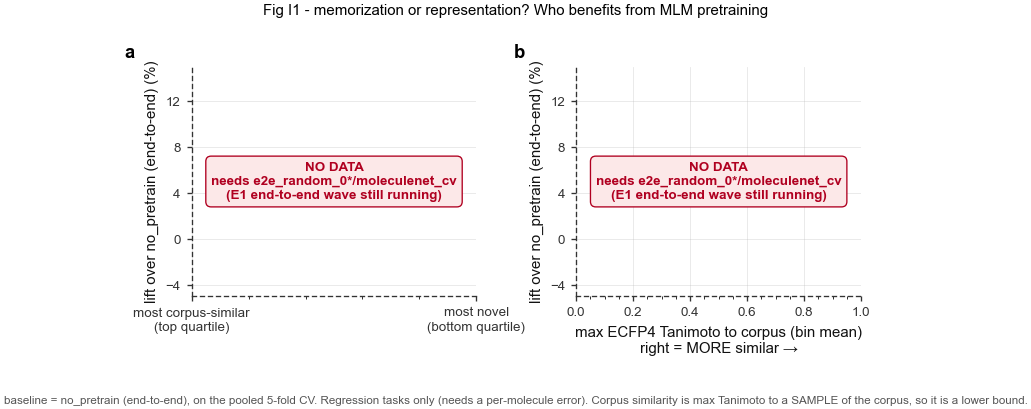

I1: no data yet. Baseline is no_pretrain (end-to-end), whose CV predictions (e2e_random_00, e2e_random_01, e2e_random_02) land with the E1 end-to-end wave.


In [12]:
# ---------- I1 · memorization vs representation ----------
TANI=DATA_ROOT/"_tanimoto"/"corpus_similarity.csv"
I1_MODEL=f"unsup_{MATCHED_BUDGET}"
# BASELINE CHOICE IS THE WHOLE POINT OF THIS PANEL.
# Lift over the FROZEN random encoder is close to trivial: that baseline cannot adapt to the task
# at all, so almost any pretraining clears it and the resulting "+34% on ESOL" says more about the
# baseline than about pretraining. The honest comparator is the random-init encoder FINE-TUNED
# end-to-end -- what a practitioner would actually do INSTEAD of pretraining. Lift over that is
# what decides whether the MLM stage buys anything, and it may well be ~0.
I1_BASELINES={"no_pretrain_e2e":["e2e_random_00","e2e_random_01","e2e_random_02"],
              "no_pretrain"    :["random_baseline_00","random_baseline_01","random_baseline_02"]}
I1_BASE_KEY="no_pretrain_e2e"          # primary; the frozen one is printed only as contrast
I1_TASKS=[t for t in ("ESOL","QM7") if t in TASKS]

def _preds(run):
    # per-molecule predictions exist only for the CV evaluation, so BOTH the model and its
    # baselines are read from CV here -- same scheme on both sides of the comparison.
    p=DATA_ROOT/"climb_v2_phase2"/run/"moleculenet_cv"/"test_predictions.csv"
    if not p.exists(): return None
    d=pd.read_csv(p)
    return (d.groupby(["dataset","raw_smiles"],as_index=False)
              .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))

def _base_preds(base_key):
    """Mean prediction across the baseline's replicates, or None if none are scored yet."""
    bs=[b for b in (_preds(r) for r in I1_BASELINES[base_key]) if b is not None]
    if not bs: return None
    return (pd.concat(bs).groupby(["dataset","raw_smiles"],as_index=False)
              .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))

def _lift_rmse(se_m,se_b):
    rm,rb=np.sqrt(np.mean(se_m)),np.sqrt(np.mean(se_b))
    return np.nan if (not np.isfinite(rb) or rb==0) else 100*(rb-rm)/rb

def binned_lift(task,base_key=None,nbins=5,nboot=400,seed=0):
    """-> (centres, lift%, lo, hi, n_per_bin) with a percentile bootstrap over molecules."""
    base_key=base_key or I1_BASE_KEY
    if not TANI.exists(): return (None,)*5
    mod=_preds(I1_MODEL); base=_base_preds(base_key)
    if mod is None or base is None: return (None,)*5
    m=mod[mod.dataset==task].merge(base[base.dataset==task],on=["dataset","raw_smiles"],
                                   suffixes=("_m","_b"))
    m=m.merge(pd.read_csv(TANI)[["raw_smiles","max_tanimoto_to_corpus"]],on="raw_smiles",how="inner")
    if len(m)<50: return (None,)*5
    m["se_m"]=(m.y_pred_m-m.y_true_m)**2; m["se_b"]=(m.y_pred_b-m.y_true_b)**2
    edges=m.max_tanimoto_to_corpus.quantile(np.linspace(0,1,nbins+1)).values; edges[0]-=1e-9
    m["bin"]=pd.cut(m.max_tanimoto_to_corpus,bins=edges,labels=False,include_lowest=True)
    rng=np.random.default_rng(seed); xs,ys,los,his,ns=[],[],[],[],[]
    for b in range(nbins):
        s=m[m.bin==b]
        if len(s)<15: continue
        sm,sb=s.se_m.values,s.se_b.values
        pt=_lift_rmse(sm,sb)
        if not np.isfinite(pt): continue
        idx=rng.integers(0,len(sm),size=(nboot,len(sm)))
        boot=np.array([_lift_rmse(sm[i],sb[i]) for i in idx]); boot=boot[np.isfinite(boot)]
        lo,hi=(np.percentile(boot,[2.5,97.5]) if len(boot) else (np.nan,np.nan))
        xs.append(float(s.max_tanimoto_to_corpus.mean())); ys.append(pt)
        los.append(lo); his.append(hi); ns.append(int(len(s)))
    return xs,ys,los,his,ns

def quartile_lift(task,base_key=None):
    """(most-similar, most-novel) lift% with bootstrap CIs, from the outer quartiles."""
    xs,ys,lo,hi,_=binned_lift(task,base_key,nbins=4)
    if not xs or len(ys)<4: return None
    return (ys[-1],lo[-1],hi[-1]),(ys[0],lo[0],hi[0])

_I1_BASE_LABEL={"no_pretrain_e2e":"no_pretrain (end-to-end)","no_pretrain":"no_pretrain (frozen)"}
_I1_HAVE=_base_preds(I1_BASE_KEY) is not None
_I1_NEED=("needs e2e_random_0*/moleculenet_cv\n(E1 end-to-end wave still running)"
          if not _I1_HAVE else "needs corpus_similarity.csv")

# Height + bottom margin reserve room for the caption INSIDE the canvas; at negative figure
# coords it only clears in the exported PNG (bbox="tight" grows it), not in the inline render.
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(STYLE["col2"],3.3))
pairs=[(t,v) for t,v in ((t,quartile_lift(t)) for t in I1_TASKS) if v]
if pairs:
    sim=float(np.mean([v[0][0] for _,v in pairs])); nov=float(np.mean([v[1][0] for _,v in pairs]))
    _se=lambda k: float(np.sqrt(np.sum([((v[k][2]-v[k][1])/2/len(pairs))**2 for _,v in pairs])))
    se_s,se_n=_se(0),_se(1)
    ax0.bar([0,1],[sim,nov],color=[PALETTE["purple"],PALETTE["teal"]],width=0.6,
            yerr=[se_s,se_n],capsize=STYLE["cap_size"],error_kw=dict(lw=STYLE["lw_thin"]))
    for xi,v,e in zip([0,1],[sim,nov],[se_s,se_n]):
        ax0.text(xi,v+e+0.6,f"{v:+.1f}%",ha="center",fontsize=STYLE["fs_annot"])
    ax0.axhline(0,color=PALETTE["black"],lw=0.6)
    lo_,hi_=min(0,sim-se_s,nov-se_n),max(0,sim+se_s,nov+se_n)
    ax0.set_ylim(lo_-abs(lo_)*0.35-2,hi_+abs(hi_)*0.35+3)
else:
    ax0.set_ylim(-5,15); no_data_watermark(ax0,_I1_NEED)
ax0.set_xticks([0,1]); ax0.set_xticklabels(["most corpus-similar\n(top quartile)","most novel\n(bottom quartile)"])
_ylab=f"lift over {_I1_BASE_LABEL[I1_BASE_KEY]} (%)"
ax0.set_ylabel(_ylab); label_all_yticks(ax0); panel_tag(ax0,"a",dx=-0.20)

col={"ESOL":PALETTE["blue"],"QM7":PALETTE["orange"]}; drew=False
for t in I1_TASKS:
    xs,ys,lo,hi,nn=binned_lift(t)
    if not xs: continue
    drew=True
    err=np.vstack([np.array(ys)-np.array(lo),np.array(hi)-np.array(ys)])
    ax1.errorbar(xs,ys,yerr=err,color=col.get(t,PALETTE["grey"]),marker="o",lw=STYLE["lw"],
                 capsize=STYLE["cap_size"],label=f"{t} (n/bin≈{int(np.median(nn))})")
if drew:
    ax1.axhline(0,color=PALETTE["black"],lw=0.6)
    ax1.legend(loc="best",fontsize=STYLE["fs_legend"])
else:
    ax1.set_ylim(-5,15); no_data_watermark(ax1,_I1_NEED)
ax1.set_xlabel("max ECFP4 Tanimoto to corpus (bin mean)\nright = MORE similar →")
ax1.set_ylabel(_ylab); label_all_yticks(ax1); panel_tag(ax1,"b",dx=-0.18)

fig.suptitle("Fig I1 - memorization or representation? Who benefits from MLM pretraining",
             fontsize=STYLE["fs_title"],y=1.04)
fig.subplots_adjust(top=0.88,bottom=0.30,wspace=0.35)
fig.text(0.5,0.05,f"baseline = {_I1_BASE_LABEL[I1_BASE_KEY]}, on the pooled 5-fold CV. Regression "
         "tasks only (needs a per-molecule error). Corpus similarity is max Tanimoto to a SAMPLE "
         "of the corpus, so it is a lower bound.",
         ha="center",va="top",fontsize=STYLE["fs_annot"],color="#555")
save_fig(fig,"figI1_memorization_vs_representation"); plt.show()

for t,v in pairs:
    print(f"I1 {t} (vs {_I1_BASE_LABEL[I1_BASE_KEY]}): most-similar {v[0][0]:+.1f}% "
          f"[{v[0][1]:+.1f},{v[0][2]:+.1f}]   most-novel {v[1][0]:+.1f}% "
          f"[{v[1][1]:+.1f},{v[1][2]:+.1f}]  (95% bootstrap CI)")
if pairs:
    # The verdict is DERIVED, not asserted. The previous version printed "overlapping CIs => no
    # evidence" unconditionally, so it would have claimed that even when the intervals separated.
    _sep=[t for t,v in pairs if v[0][1]>v[1][2] or v[1][1]>v[0][2]]
    if _sep:
        print(f"Non-overlapping CIs on {', '.join(_sep)} => the gain DOES depend on corpus "
              f"similarity there; memorization cannot be ruled out.")
    else:
        print("CIs overlap on every task => no evidence the gain concentrates on corpus-similar "
              "molecules, i.e. consistent with representation rather than memorization.")
    # Same analysis against the weak frozen baseline, printed for contrast so the effect of the
    # baseline choice on the headline number is visible rather than argued about.
    if _base_preds("no_pretrain") is not None:
        print("\n   contrast - the SAME comparison against the frozen baseline (why we switched):")
        for t in I1_TASKS:
            v=quartile_lift(t,"no_pretrain")
            if v: print(f"   {t}: most-similar {v[0][0]:+.1f}%   most-novel {v[1][0]:+.1f}%  "
                        f"(vs no_pretrain frozen)")
else:
    print(f"I1: no data yet. Baseline is {_I1_BASE_LABEL[I1_BASE_KEY]}, whose CV predictions "
          f"({', '.join(I1_BASELINES[I1_BASE_KEY])}) land with the E1 end-to-end wave.")

## H1 · Does SMILES enumeration beat canonical repetition?

Beyond one epoch a model must re-see molecules. Enumeration re-shows each molecule under a
*different* valid SMILES string; canonical re-shows the identical string. If enumeration were
meaningful augmentation rather than noise, its curve should separate as the unique-molecule
fraction shrinks and repetition rises.

saved figH1_canonical_vs_enumerated


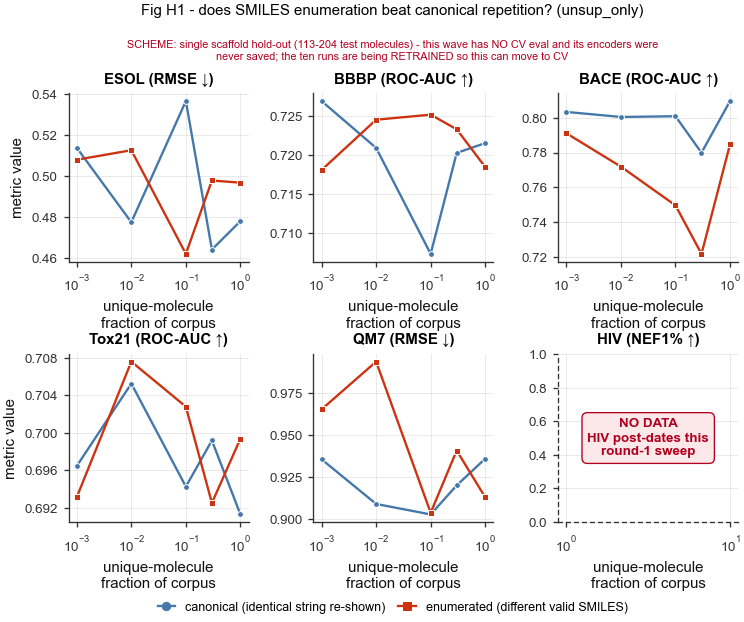

H1 scheme: single scaffold hold-out (113-204 test molecules) - this wave has NO CV eval and its encoders were never saved; the ten runs are being RETRAINED so this can move to CV
H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:
   frac=0.001  mean relative change -1.05%  (n=5)
   frac=0.01   mean relative change -3.88%  (n=5)
   frac=0.1    mean relative change +2.23%  (n=5)
   frac=0.3    mean relative change -3.50%  (n=5)
   frac=1.0    mean relative change -0.76%  (n=5)


In [13]:
# ---------- H1 · canonical vs enumerated SMILES ----------
# SCHEME: this round-1 wave was only ever scored on the single DeepChem scaffold hold-out, so the
# y-values are 113-204-molecule estimates on the small tasks -- not the 5-fold CV every other
# panel now uses. It CANNOT simply be re-scored: `climb_v2`'s encoder weights were never uploaded
# (zero `encoder/` objects under s3://climb-s3-bucket/experiments/climb_v2/), so moving H1 to CV
# means RETRAINING all ten runs -- which is now under way. This cell upgrades itself the moment a
# CV eval appears, so no edit is needed when that lands.
H1_SUB="moleculenet_cv" if list(Path(f"{DATA_ROOT}/climb_v2").glob("scaling_*/moleculenet_cv")) else "moleculenet"
FRACS=[("frac0p001",0.001),("frac0p01",0.01),("frac0p1",0.1),("frac0p3",0.3),("fracfull",1.0)]
# Six panels in a single row overlapped titles, tick labels and axis labels. 3x2 matches A1.
ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.35*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    drew=False
    for mode,c,mk in [("canonical",PALETTE["blue"],"o"),("enumerated",PALETTE["red"],"s")]:
        xs,ys=[],[]
        for fk,fv in FRACS:
            d=load_suite(DATA_ROOT/"climb_v2"/f"scaling_{mode}_{fk}",sub=H1_SUB)
            sk=TASKS[task].get("suite_key",task)
            if d and (sk,"mean") in d: xs.append(fv); ys.append(d[(sk,"mean")])
        if xs: drew=True; ax.plot(xs,ys,color=c,marker=mk,ms=3.5,lw=STYLE["lw"],mec="white")
    ax.set_xscale("log"); ax.set_title(ttitle(task,oneline=True),pad=6)
    ax.set_xlabel("unique-molecule\nfraction of corpus")
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,"HIV post-dates this\nround-1 sweep")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")
handles=[plt.Line2D([],[],color=PALETTE["blue"],marker="o",label="canonical (identical string re-shown)"),
         plt.Line2D([],[],color=PALETTE["red"], marker="s",label="enumerated (different valid SMILES)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
_h1scheme=("pooled 5-fold scaffold CV" if H1_SUB=="moleculenet_cv" else
           "single scaffold hold-out (113-204 test molecules) - this wave has NO CV eval and its "
           "encoders were never saved; the ten runs are being RETRAINED so this can move to CV")
fig.suptitle("Fig H1 - does SMILES enumeration beat canonical repetition? (unsup_only)",
             fontsize=STYLE["fs_title"],y=1.06)
fig.text(0.5,0.995,"\n".join(_tw.wrap(f"SCHEME: {_h1scheme}",110)),ha="center",va="top",
         fontsize=STYLE["fs_annot"]-0.5,color=("#666" if H1_SUB=="moleculenet_cv" else "#B00020"))
fig.subplots_adjust(top=0.90,bottom=0.14,hspace=0.55,wspace=0.36)
save_fig(fig,"figH1_canonical_vs_enumerated"); plt.show()

print(f"H1 scheme: {_h1scheme}")
print("H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:")
for fk,fv in FRACS:
    ds={m:load_suite(DATA_ROOT/"climb_v2"/f"scaling_{m}_{fk}",sub=H1_SUB) for m in ("canonical","enumerated")}
    if not all(ds.values()): continue
    d=[]
    for t in CORE_TASKS:
        sk=TASKS[t].get("suite_key",t)
        if all((sk,"mean") in ds[m] for m in ds):
            f=ds["canonical"][(sk,"mean")]
            d.append(lift(ds["enumerated"][(sk,"mean")],t,f))
    if d: print(f"   frac={fv:<6} mean relative change {100*np.nanmean(d):+.2f}%  (n={len(d)})")

## Figure inventory — which figures are FINAL, and which are still moving

"Can I write this number down?" gets one answer per figure, **computed** rather than remembered.
A figure is FINAL when every summary it reads came from the current `eval_v2` and nothing it plots
is still pending. `eval_v2` gained `<metric>_train` and HIV NEF1% on 2026-07-21; re-scoring the
*same* encoder with it moves a metric by up to 0.03, so an older summary is not merely old — it is
a different protocol, and a panel that mixes the two is comparing two scorers.

In [14]:
# ---------- inventory: is each exported figure FINAL, or still moving? ----------
EVAL_BUILD = pd.Timestamp("2026-07-21")   # the eval_v2 build every final figure must be scored by

def _sums(pattern,sub="moleculenet"):
    return [Path(q) for q in glob.glob(f"figure_data/{pattern}/{sub}/suite_summary.json")]

# what each figure actually reads off disk
FIG_SOURCES={
  "A1.a": _sums("climb_v2_phase2/*"),
  "A1.b": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "A2.a": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "A2.b": _sums("climb_v2_phase2/*","moleculenet_cv"),
  "B1p1": [Path(q) for q in glob.glob(f"{LE}/*/moleculenet/moleculenet_summary.csv")],
  # E1's frozen line is read per head seed straight from the phase-2 summaries, so its verdict
  # depends on those too -- not only on the cached eval_ceiling.csv.
  "E1"  : [q for q in (CEIL,CEIL_SUP) if q.exists()]
          +[q for r in ("random_baseline_00","unsup_2M","unsup_8M","unsup_24M",
                        f"skip_{E1_SUP_RECIPE}_2M",f"skip_{E1_SUP_RECIPE}_8M",f"skip_{E1_SUP_RECIPE}_24M")
              for q in _sums(f"climb_v2_phase2/{r}")],
  "B2"  : _sums("climb_v2_phase2/*"),
  "C1J1": _sums("climb_v2_ablation_dedup/*")+_sums("climb_v2_phase2/unsup_2M"),
  "I1"  : _sums("climb_v2_phase2/*","moleculenet_cv"),
  "H1"  : _sums("climb_v2/scaling_*"),
}
# blockers that are MISSING work rather than stale scoring
_missing_hiv=sorted(set(DF.run)-set(DF[DF.task=="HIV"].run))
_u2s_seeds=DF[(DF.regime=="unsup2sup")&(DF.budget_label==MATCHED_BUDGET)].seed.nunique()
_missing_hiv_cv=sorted(set(DF_CV.run)-set(DF_CV[DF_CV.task=="HIV"].run))
_e2e=len(DF[DF.regime=="no_pretrain_e2e"])
BLOCKERS={
  "A1.a": ([f"{len(_missing_hiv)} runs lack HIV NEF1%"] if _missing_hiv else [])
        +([f"unsup→sup has {_u2s_seeds} pretraining seed: its error bar is head-seed only"]
          if _u2s_seeds<2 else [])
        +([] if _e2e else ["no_pretrain_end_to_end (E1) not run"]),
  "A1.b": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e else ["no_pretrain_end_to_end (E1) not run"]),
  "A2.a": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e else ["no_pretrain_end_to_end (E1) not run"])
        +["96M rung + unsup→sup 48M have no CV eval",
          "~100M-molecule unsupervised rung (full PubChem still downloading)"],
  "A2.b": ([f"{len(_missing_hiv_cv)} runs lack HIV in the CV eval"] if _missing_hiv_cv else [])
        +([] if _e2e else ["no_pretrain_end_to_end (E1) not run"])
        +["~100M-molecule unsupervised rung (full PubChem still downloading)"],
  "B2": ([] if _have_b2 else ["corrupt_mlm_8M / corrupt_mtr_8M still training"]),
  "E1": list(_E1_PENDING and [f"sup_only ladder not fine-tuned yet: {', '.join(_E1_PENDING)}"] or []),
  # A figure is not FINAL just because its files are consistent -- a declared arm with no runs is
  # a gap too. B1p1 carries no_pretrain_e2e in its legend as NOT RUN; C1J1's whole wave was scored
  # only on the small single hold-out, so its effect sizes are the weakest in the notebook.
  "B1p1": ([] if glob.glob(f"{LE}/e2e_n*/moleculenet/moleculenet_summary.csv")
           else ["no_pretrain_end_to_end label sweep not run (legend says NOT RUN)"]),
  "H1"  : ([] if H1_SUB=="moleculenet_cv"
           else ["round-1 wave has NO CV eval and no saved encoders - retraining under way"]),
  "I1"  : ([] if _I1_HAVE else ["baseline is now no_pretrain_e2e; its CV predictions land with "
                                "the E1 wave"]),
  "C1J1": ([] if glob.glob(f"figure_data/{ABL}/*/moleculenet_cv/suite_summary.json")
           else ["ablation wave has NO 5-fold CV eval - single hold-out only (113-204 test mols)"]),
}

FIGS=[("A1.a","figA1a_best_model_headline_holdout","which model performs best (8M, single scaffold hold-out)"),
      ("A1.b","figA1b_best_model_headline_cv","which model performs best (8M, pooled 5-fold scaffold CV)"),
      ("A2.a","figA2a_scaling_forward_passes","scaling in pretraining compute"),
      ("A2.b","figA2b_scaling_unique_molecules","scaling in unique molecules seen"),
      ("B1p1","figB1p1_label_efficiency_train_test","label-efficiency + fit/generalize mechanism"),
      ("E1","figE1_H5_eval_ceiling","H5: is the sup/unsup ordering a frozen-probe artifact?"),
      ("B2","figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER"),"corrupted-pretraining control"),
      ("C1J1","figC1J1_sft_family_transfer","SFT family: which helps, how much, does it track chemistry"),
      ("I1","figI1_memorization_vs_representation","memorization vs representation"),
      ("H1","figH1_canonical_vs_enumerated","canonical vs enumerated SMILES")]
out=Path(STYLE["outdir"]); final=[]
print(f"{'fig':<6} {'verdict':<12} {'exported':<44} {'files':<7} status")
for fid,name,what in FIGS:
    both=(out/f"{name}.png").exists() and (out/f"{name}.pdf").exists()
    srcs=[q for q in FIG_SOURCES.get(fid,[]) if q.exists()]
    old=[q for q in srcs if pd.Timestamp(q.stat().st_mtime,unit="s")<EVAL_BUILD]
    blk=list(BLOCKERS.get(fid,[]))
    # What disqualifies a figure is MIXING two scorers, not being scored by the older one. H1
    # compares canonical vs enumerated entirely within one round-1 wave: internally consistent,
    # so it is final even though it predates the current build. A1 mixing 07-19 and 07-22
    # summaries is not.
    stale = old if (old and len(old)<len(srcs)) else []
    if stale: blk.insert(0,f"MIXED scorers: {len(stale)}/{len(srcs)} summaries predate the rest")
    elif old: what += "  [scored by the pre-2026-07-21 eval_v2, but consistently so]"
    verdict="FINAL" if (both and not blk) else ("PROVISIONAL" if both else "NOT EXPORTED")
    if verdict=="FINAL": final.append(fid)
    print(f"{fid:<6} {verdict:<12} {name:<44} {'png+pdf' if both else 'MISSING':<7} "
          f"{'; '.join(blk) if blk else what}")
    for q in sorted(stale)[:3]:
        print(f"{'':<6} {'':<12}   stale: {'/'.join(q.parts[1:3])}")

print(f"\nFINAL - safe to quote: {', '.join(final) if final else '(none)'}")
prov=[f for f,_,_ in FIGS if f not in final]
if prov: print(f"PROVISIONAL - do NOT quote effect sizes yet: {', '.join(prov)}")
stray=sorted(p.name for p in out.glob("*") if p.stem not in {n for _,n,_ in FIGS})
print("stray files in figures_out (not one of the exported set):", stray or "none")

fig    verdict      exported                                     files   status
A1.a   PROVISIONAL  figA1a_best_model_headline_holdout           png+pdf no_pretrain_end_to_end (E1) not run
A1.b   PROVISIONAL  figA1b_best_model_headline_cv                png+pdf 18 runs lack HIV in the CV eval; no_pretrain_end_to_end (E1) not run
A2.a   PROVISIONAL  figA2a_scaling_forward_passes                png+pdf 18 runs lack HIV in the CV eval; no_pretrain_end_to_end (E1) not run; 96M rung + unsup→sup 48M have no CV eval; ~100M-molecule unsupervised rung (full PubChem still downloading)
A2.b   PROVISIONAL  figA2b_scaling_unique_molecules              png+pdf 18 runs lack HIV in the CV eval; no_pretrain_end_to_end (E1) not run; ~100M-molecule unsupervised rung (full PubChem still downloading)
B1p1   PROVISIONAL  figB1p1_label_efficiency_train_test          png+pdf no_pretrain_end_to_end label sweep not run (legend says NOT RUN)
E1     FINAL        figE1_H5_eval_ceiling                        png+pd